# Постковидные осложнения: динамика по периодам 6 / 12 / 24 месяца

Работа анализирует **поздние (постковидные) осложнения** с разбивкой по трём окнам наблюдения —
**6, 12 и 24 месяца** — и оценивает, какие показатели **острого периода** и какие **независимые признаки**
предсказывают эти осложнения, как это меняется во времени и между **штаммами вируса**.

**Данные.** `6_12_24.xlsx`, листы `Ухань` (213), `Дельта` (272), `Омикрон` (270) — всего **755** пациентов.
Осложнения занесены **инцидентно по окнам** (6 / 12 / 24 мес): значение в столбце «12 мес» — это осложнения,
проявившиеся в интервале до 12 месяцев, а не накопленный итог. Признак **«за весь период»** формируем как
объединение трёх окон.

**Две группы предикторов**

| Острый период (набор A) | Независимые признаки (набор B) |
|---|---|
| СРБ, ЛДГ, IL-6, ФНО-α, вит. D, IL-18, Д-димер, ОРДС, бактер. осложнения | ИМТ, возраст, пол, КТ (итог), HOMA-IR, TyG, вакцинация, ГКС, сопутствующие: ЖКТ / ССС / СД |

**Структура**

- **Часть 1.** Предикторы осложнений (наборы A и B): отношения шансов (OR) и **важность признаков
  (случайный лес)** — **в целом и по периодам** 6/12/24, **в целом и по отдельным осложнениям**; диаграммы
  распространённости в целом и по окнам.
- **Часть 2.** То же **с учётом повторного COVID** по каждой нозологии.
- **Часть 3.** То же **по штаммам** + сравнение частот и предикторов между штаммами и по месяцам.
- **Часть 4.** **SHAP-разбор** независимых признаков по штаммам и месяцам.
- **Часть 5.** **Детальные предикторы** отдельных нозологий (пневмонии, ССЗ/АГ, СД, флеботромбоз — по
  штаммам и периодам; ОНМК/ИМ — по периодам): инцидентность и важность независимых признаков.

> **Охват моделей.** Модели важности / OR / SHAP строятся для обеспеченных числом событий исходов
> (**любое осложнение, ССЗ/АГ, зрение/слух, рецидивирующие пневмонии, ЖКТ/МАЖБП, психика/ЦНС**). Диаграммы
> распространённости приводятся по **всем** нозологиям; редкие (< ~15 событий) помечаются как поисковые.
> *OR/SD* — отношение шансов на +1 стандартное отклонение непрерывного признака; для бинарных — обычное OR.


## 0.1 Подготовка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score

from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
RANDOM_STATE = 42

STRAINS = ['Ухань', 'Дельта', 'Омикрон']
STRAIN_COLORS = {'Ухань': '#4C72B0', 'Дельта': '#DD8452', 'Омикрон': '#55A868'}
PERIODS = ['6 мес', '12 мес', '24 мес']
PERIOD_COLORS = {'6 мес': '#9ecae1', '12 мес': '#4292c6', '24 мес': '#08519c'}

def fmt_p(p):
    if pd.isna(p):
        return '—'
    return '<0.001' if p < 0.001 else f'{p:.3f}'

def stars(p):
    return '' if pd.isna(p) else ('***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else '')
print('Окружение готово')

Окружение готово


## 0.2 Загрузка данных, исходы и предикторы

Объединяем три листа по штаммам (755 пациентов). Для каждой нозологии есть три столбца (6/12/24 мес);
исход «за весь период» — их объединение. Осложнения бинаризуем (≥1 эпизод → 1).

In [2]:
FILE_PATH = '6_12_24.xlsx'
G = pd.concat([pd.read_excel(FILE_PATH, sheet_name=s, header=0).assign(Штамм=s) for s in STRAINS],
              ignore_index=True).copy()
G['Штамм'] = pd.Categorical(G['Штамм'], categories=STRAINS, ordered=True)
N = len(G)
print(f'Загружено: {N} пациентов ({", ".join(f"{s}={int((G.Штамм==s).sum())}" for s in STRAINS)})')

def col(i):
    return pd.to_numeric(G.iloc[:, i], errors='coerce')

def binz(i):
    return (col(i).fillna(0) > 0).astype(int)

# --- нозологии: подпись -> (индекс_6, индекс_12, индекс_24) ---
ALL_TRIPLES = {
    'Любое осложнение':     (130, 131, 132),
    'ССЗ / АГ':             (134, 135, 136),
    'Зрение / слух':        (149, 150, 151),
    'Рецидив. пневмонии':   (162, 163, 164),
    'ЖКТ / МАЖБП':          (174, 175, 176),
    'Психика / ЦНС':        (152, 153, 154),
    'Флеботромбоз':         (140, 141, 142),
    'Пост. слабость':       (158, 159, 160),
    'СД / эндокринные':     (146, 147, 148),
    'Пневмофиброз':         (168, 169, 170),
    'ОНМК / ИМ':            (165, 166, 167),
    'АСТМА / ХОБЛ':         (171, 172, 173),
    'Некроз / суставы':     (137, 138, 139),
    'Онкология':            (143, 144, 145),
    'Панкреонекроз':        (155, 156, 157),
}
# исходы для моделей (достаточно событий)
MODEL_COMPS = ['Любое осложнение', 'ССЗ / АГ', 'Зрение / слух', 'Рецидив. пневмонии', 'ЖКТ / МАЖБП', 'Психика / ЦНС']

def comp_any(name):
    a, b, c = ALL_TRIPLES[name]
    return ((col(a).fillna(0) > 0) | (col(b).fillna(0) > 0) | (col(c).fillna(0) > 0)).astype(int)

def comp_period(name, k):        # k = 0,1,2  -> 6,12,24
    return binz(ALL_TRIPLES[name][k])

# --- предикторы: (подпись, индекс, тип)  c=непрерывный, b=бинарный, f=пол(жен=1) ---
ACUTE_SPEC = [('СРБ', 75, 'c'), ('ЛДГ', 74, 'c'), ('IL-6', 111, 'c'), ('ФНО-α', 112, 'c'),
              ('вит. D', 78, 'c'), ('IL-18', 117, 'c'), ('Д-димер', 77, 'c'),
              ('ОРДС', 110, 'b'), ('Бактер. осл.', 120, 'b')]
INDEP_SPEC = [('ИМТ', 31, 'c'), ('Возраст', 2, 'c'), ('Пол: жен', 3, 'f'), ('КТ (итог)', 38, 'c'),
              ('HOMA-IR', 115, 'c'), ('TyG', 70, 'c'), ('Вакцинация', 10, 'b'), ('ГКС', 93, 'b'),
              ('Сопут.: ЖКТ', 86, 'b'), ('Сопут.: ССС', 83, 'b'), ('Сопут.: СД', 85, 'b')]

def make_feat(idx, kind):
    if kind == 'c':
        s = col(idx); return s.fillna(s.median())
    if kind == 'f':
        return (col(idx) == 2).astype(int)
    s = col(idx)                                  # 'b' — бинарный; служебные значения (напр. 9) → 0
    return s.where(s.isin([0, 1])).fillna(0).astype(int)

XA = pd.DataFrame({nm: make_feat(i, k) for nm, i, k in ACUTE_SPEC})
XB = pd.DataFrame({nm: make_feat(i, k) for nm, i, k in INDEP_SPEC})
CONT_A = {nm for nm, i, k in ACUTE_SPEC if k == 'c'}
CONT_B = {nm for nm, i, k in INDEP_SPEC if k == 'c'}
repeat_covid = binz(133)         # повторный COVID-19

print(f'Острых маркёров (A): {XA.shape[1]} | независимых признаков (B): {XB.shape[1]}')
print(f'Повторный COVID-19: {int(repeat_covid.sum())} пациентов')

Загружено: 755 пациентов (Ухань=213, Дельта=272, Омикрон=270)
Острых маркёров (A): 9 | независимых признаков (B): 11
Повторный COVID-19: 65 пациентов


### Вспомогательные функции (OR, важность RF, AUC)

In [3]:
def or_uni(y, x, continuous):
    """Однофакторное OR (95% ДИ, p); для непрерывных — на +1 SD. NaN при вырождении/сепарации."""
    y = np.asarray(y)
    if y.sum() < 8 or (len(y) - y.sum()) < 8:
        return np.nan, np.nan, np.nan, np.nan
    xv = (x - x.mean()) / x.std() if continuous else x.astype(float)
    if np.std(xv) == 0:
        return np.nan, np.nan, np.nan, np.nan
    try:
        r = sm.Logit(y, sm.add_constant(pd.DataFrame({'x': xv}))).fit(disp=0)
        orr = np.exp(r.params.iloc[1])
        if not np.isfinite(orr) or orr > 50 or orr < 0.02:
            return np.nan, np.nan, np.nan, np.nan
        ci = np.exp(r.conf_int()).iloc[1]
        return orr, ci.iloc[0], ci.iloc[1], r.pvalues.iloc[1]
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

def rf_new(n=400):
    return RandomForestClassifier(n_estimators=n, max_depth=4, min_samples_leaf=15,
                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

def cv_auc(X, y):
    """AUC на повторной кросс-валидации (3 блока × 5 повторов): (среднее, SD). NaN при <12 событий."""
    y = np.asarray(y)
    if y.sum() < 12 or (len(y) - y.sum()) < 12:
        return np.nan, np.nan
    try:
        sc = cross_val_score(rf_new(), X, y, scoring='roc_auc',
                             cv=RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=RANDOM_STATE))
        return sc.mean(), sc.std()
    except Exception:
        return np.nan, np.nan

def rf_importance(X, y):
    """Permutation importance (падение ROC-AUC при перестановке признака) — беспристрастна к типу
    признака (в отличие от Gini). None при <12 событий; отрицательные значения (шум) обнуляются."""
    y = np.asarray(y)
    if y.sum() < 12 or (len(y) - y.sum()) < 12:
        return None
    rf = rf_new(); rf.fit(X, y)
    rf.n_jobs = 1                        # без вложенного параллелизма (permutation сам параллелит)
    pi = permutation_importance(rf, X, y, scoring='roc_auc', n_repeats=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
    return pd.Series(np.clip(pi.importances_mean, 0, None), index=X.columns)
print('OK')

OK


## 0.3 Распространённость осложнений — в целом и по периодам

Сначала — частота каждой нозологии **за весь период наблюдения** (объединение окон), затем — **инцидентно
по окнам 6 / 12 / 24 месяца** (сколько новых случаев проявилось в каждом интервале).

Число случаев (инцидентно по окнам) и за весь период наблюдения:


,6 мес,12 мес,24 мес,За весь период,"Частота, %"
Любое осложнение,103,192,136,357,47.300
ЖКТ / МАЖБП,43,80,74,196,26.000
Рецидив. пневмонии,55,97,66,174,23.000
Зрение / слух,41,70,40,150,19.900
ССЗ / АГ,41,47,27,114,15.100
Пост. слабость,33,35,21,88,11.700
Психика / ЦНС,19,40,21,80,10.600
Флеботромбоз,24,24,9,51,6.800
СД / эндокринные,11,24,9,42,5.600
Пневмофиброз,12,13,13,37,4.900


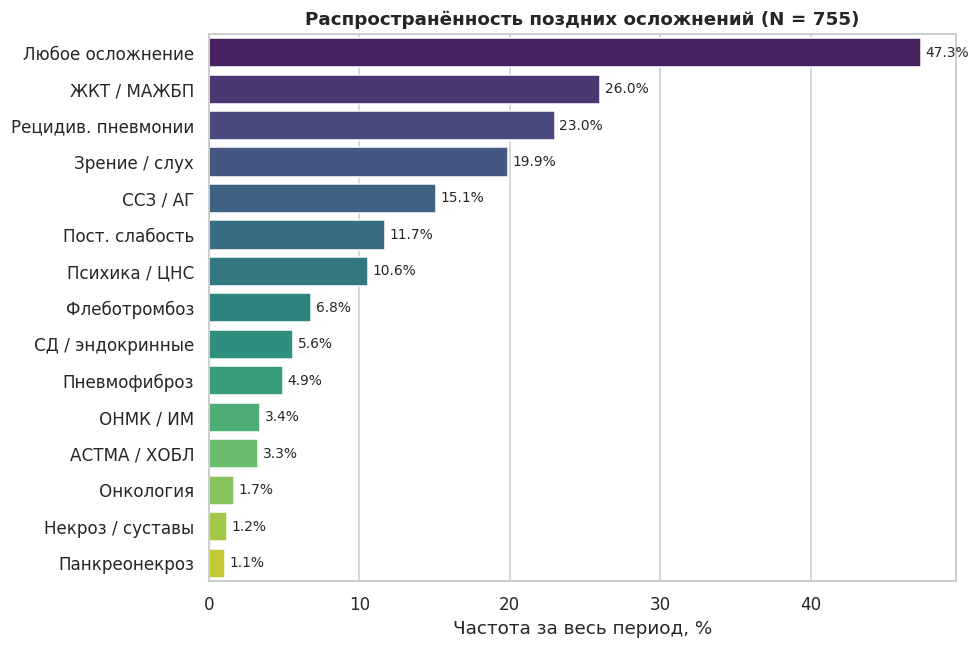

In [4]:
prev = pd.DataFrame({
    '6 мес': [comp_period(nm, 0).sum() for nm in ALL_TRIPLES],
    '12 мес': [comp_period(nm, 1).sum() for nm in ALL_TRIPLES],
    '24 мес': [comp_period(nm, 2).sum() for nm in ALL_TRIPLES],
    'За весь период': [comp_any(nm).sum() for nm in ALL_TRIPLES],
}, index=list(ALL_TRIPLES)).astype(int)
prev['Частота, %'] = (100 * prev['За весь период'] / N).round(1)
prev_sorted = prev.sort_values('За весь период', ascending=False)
print('Число случаев (инцидентно по окнам) и за весь период наблюдения:')
display(prev_sorted)

# --- диаграмма 1: распространённость за весь период (все нозологии) ---
fig, ax = plt.subplots(figsize=(9, 6))
d = prev_sorted['Частота, %']
sns.barplot(x=d.values, y=d.index, hue=d.index, palette='viridis', legend=False, ax=ax)
for i, v in enumerate(d.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Частота за весь период, %'); ax.set_ylabel('')
ax.set_title(f'Распространённость поздних осложнений (N = {N})', fontweight='bold')
plt.tight_layout(); plt.show()

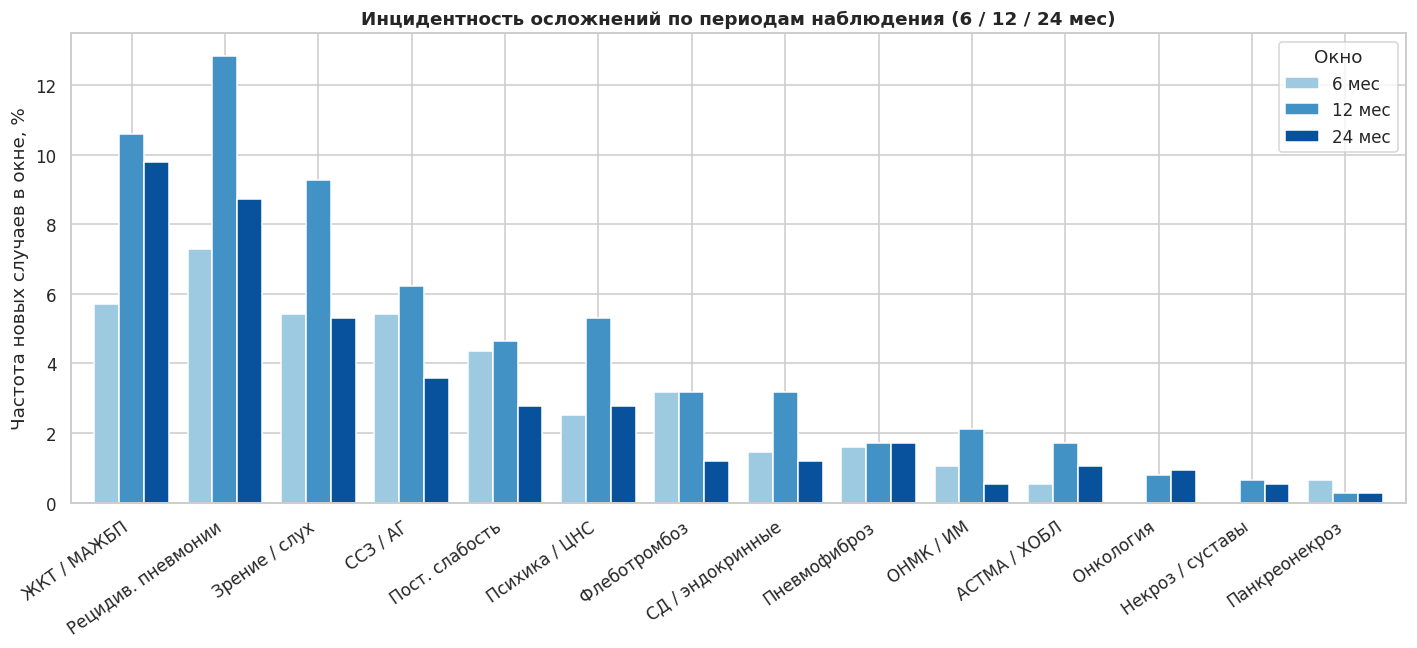

«Любое осложнение» по окнам: 6 мес=103, 12 мес=192, 24 мес=136


In [5]:
# --- диаграмма 2: инцидентность по окнам 6/12/24 (все нозологии, кроме «любое») ---
noso = [nm for nm in prev_sorted.index if nm != 'Любое осложнение']
byp = prev.loc[noso, ['6 мес', '12 мес', '24 мес']]
byp_pct = 100 * byp / N
fig, ax = plt.subplots(figsize=(13, 6))
byp_pct.plot(kind='bar', ax=ax, color=[PERIOD_COLORS[p] for p in PERIODS], width=0.8)
ax.set_ylabel('Частота новых случаев в окне, %'); ax.set_xlabel('')
ax.set_title('Инцидентность осложнений по периодам наблюдения (6 / 12 / 24 мес)', fontweight='bold')
ax.legend(title='Окно')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
print('«Любое осложнение» по окнам: ' + ', '.join(f'{p}={int(prev.loc["Любое осложнение", p])}' for p in PERIODS))

---
# Часть 1. Предикторы осложнений: острый период и независимые признаки

Оцениваем связь предикторов с осложнениями двумя способами: **отношение шансов (OR)** — сила и направление
однофакторной связи, и **важность признаков (permutation importance)** случайного леса с качеством модели по **AUC** на
кросс-валидации. Всё считаем **в целом** (исход за весь период) и **по периодам** 6/12/24, для набора A
(острый период) и набора B (независимые признаки).

## 1.1 Отношения шансов: признак × осложнение (за весь период)

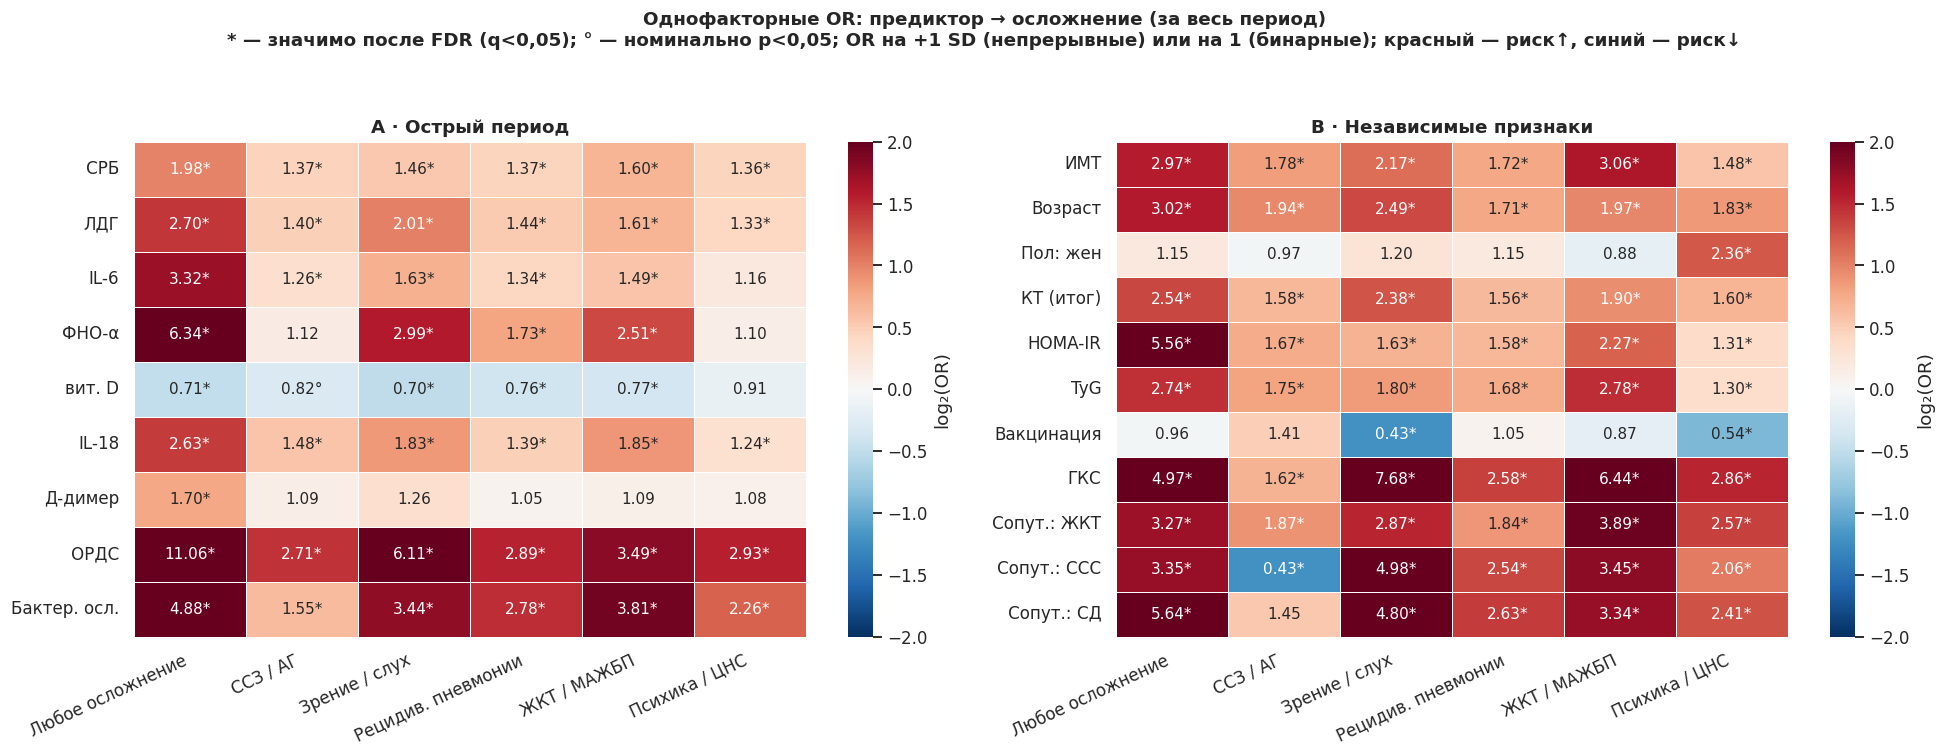

In [6]:
def or_matrix(Xset, cont_set):
    OR = pd.DataFrame(index=Xset.columns, columns=MODEL_COMPS, dtype=float)
    PV = pd.DataFrame(index=Xset.columns, columns=MODEL_COMPS, dtype=float)
    for cn in MODEL_COMPS:
        y = comp_any(cn)
        for f in Xset.columns:
            orr, lo, hi, p = or_uni(y, Xset[f], f in cont_set)
            OR.loc[f, cn] = orr; PV.loc[f, cn] = p
    flat = PV.values.astype(float).flatten(); ok = ~np.isnan(flat)      # FDR внутри набора
    q = np.full_like(flat, np.nan); q[ok] = multipletests(flat[ok], method='fdr_bh')[1]
    Q = pd.DataFrame(q.reshape(PV.shape), index=PV.index, columns=PV.columns)
    return OR, PV, Q

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, (Xset, cont_set, ttl) in zip(axes, [(XA, CONT_A, 'A · Острый период'), (XB, CONT_B, 'B · Независимые признаки')]):
    OR, PV, Q = or_matrix(Xset, cont_set)
    L = np.log2(OR.astype(float))
    annot = OR.copy().astype(object)
    for f in OR.index:
        for cn in OR.columns:
            o, p, qq = OR.loc[f, cn], PV.loc[f, cn], Q.loc[f, cn]
            mark = '*' if (not pd.isna(qq) and qq < 0.05) else ('°' if (not pd.isna(p) and p < 0.05) else '')
            annot.loc[f, cn] = '' if pd.isna(o) else f'{o:.2f}{mark}'
    sns.heatmap(L, annot=annot.values, fmt='', cmap='RdBu_r', center=0, vmin=-2, vmax=2, linewidths=0.5,
                mask=OR.isna().values, cbar_kws={'label': 'log₂(OR)'}, ax=ax)
    ax.set_facecolor('#EDEDED')
    ax.set_title(f'{ttl}', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right'); ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Однофакторные OR: предиктор → осложнение (за весь период)\n'
             '* — значимо после FDR (q<0,05); ° — номинально p<0,05; OR на +1 SD (непрерывные) или на 1 (бинарные); красный — риск↑, синий — риск↓',
             y=1.05, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 1.2 Важность признаков (permutation importance) — в целом, по осложнениям

Важность измеряем **permutation importance** — падением ROC-AUC при случайной перестановке признака.
В отличие от Gini-важности случайного леса, она **не смещена** в сторону непрерывных признаков и корректно
оценивает вклад бинарных (пол, сопутствующие, вакцинация).

> Важность оценивается **на обучающей выборке** (train-set permutation importance) — величины несколько
> оптимистичны, особенно на малых подвыборках; для крупных исходов этот эффект незначителен, а в Части 5
> ячейки с ненадёжной моделью (нижняя граница AUC ≤ 0,5) не показываются.

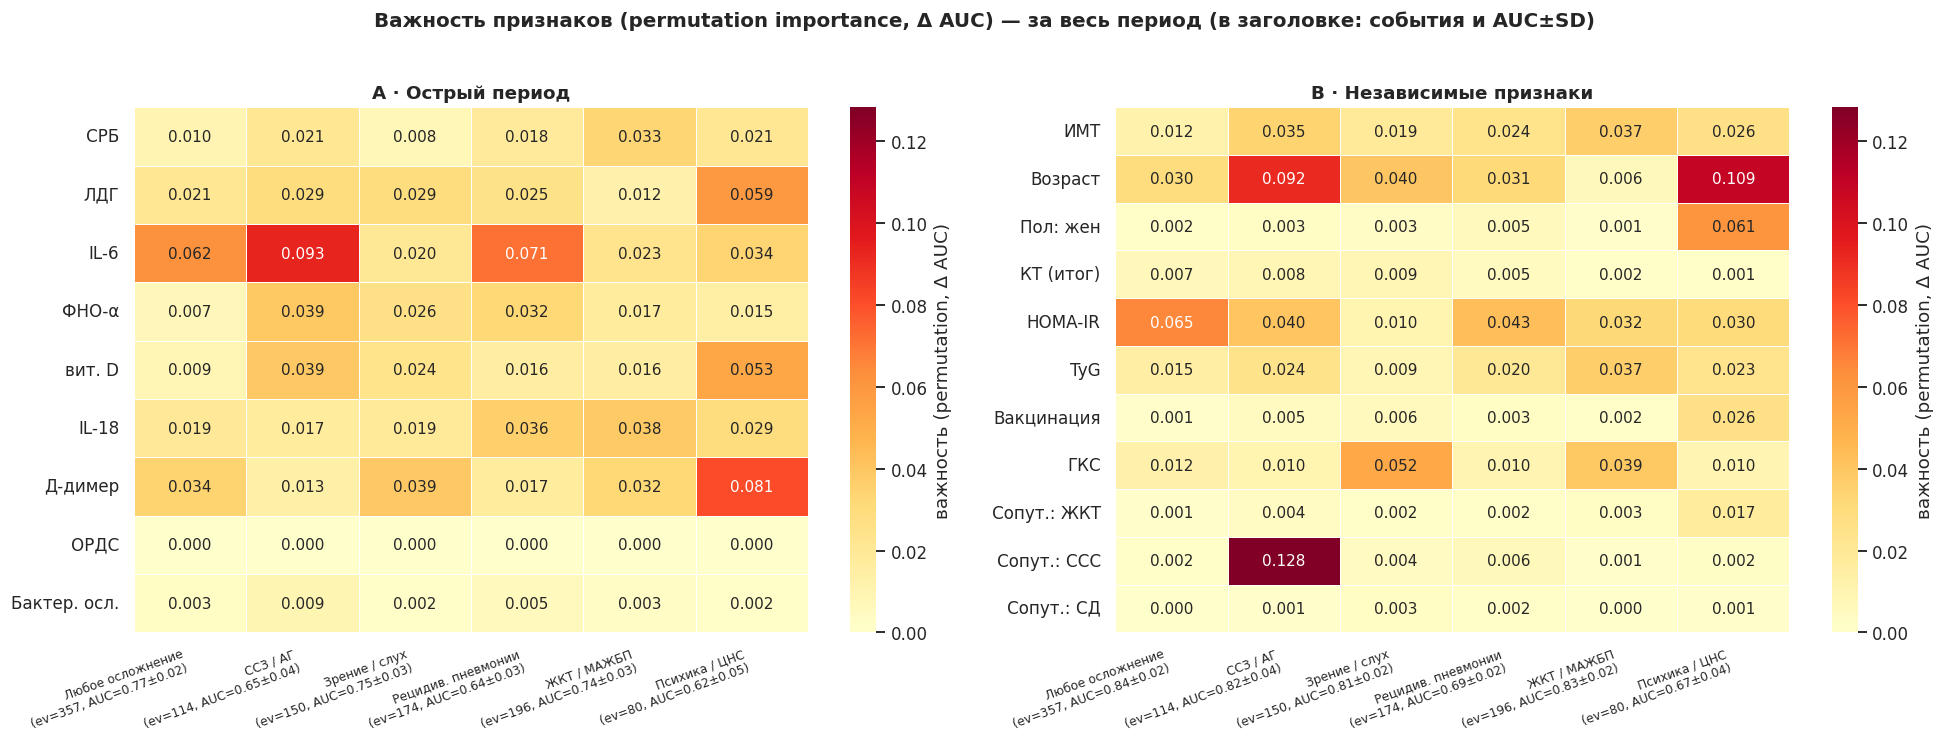

In [7]:
def imp_matrix(Xset):
    IMP = pd.DataFrame(index=Xset.columns, dtype=float); aucs = {}
    for cn in MODEL_COMPS:
        y = comp_any(cn)
        imp = rf_importance(Xset, y); aucs[cn] = cv_auc(Xset, y)
        IMP[cn] = imp.reindex(Xset.columns) if imp is not None else np.nan
    return IMP, aucs

mats = {tag: imp_matrix(Xset) for tag, Xset in [('A', XA), ('B', XB)]}
imp_store = mats
vmax = max(np.nanmax(mats['A'][0].values), np.nanmax(mats['B'][0].values))
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, (tag, ttl) in zip(axes, [('A', 'A · Острый период'), ('B', 'B · Независимые признаки')]):
    IMP, aucs = mats[tag]
    headers = [f'{cn}\n(ev={int(comp_any(cn).sum())}, AUC={aucs[cn][0]:.2f}±{aucs[cn][1]:.2f})' for cn in MODEL_COMPS]
    sns.heatmap(IMP.astype(float), annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=vmax, linewidths=0.5,
                mask=IMP.isna().values, cbar_kws={'label': 'важность (permutation, Δ AUC)'}, ax=ax)
    ax.set_facecolor('#EDEDED'); ax.set_title(f'{ttl}', fontweight='bold')
    ax.set_xticklabels(headers, rotation=20, ha='right', fontsize=8); ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Важность признаков (permutation importance, Δ AUC) — за весь период (в заголовке: события и AUC±SD)',
             y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 1.3 Важность признаков по периодам (6 / 12 / 24 мес)

Как меняется вклад признаков во времени. Для каждого набора — тепловая карта «признак × период» для
**любого осложнения**; ниже — таблица ведущего признака для каждой пары «осложнение × период».

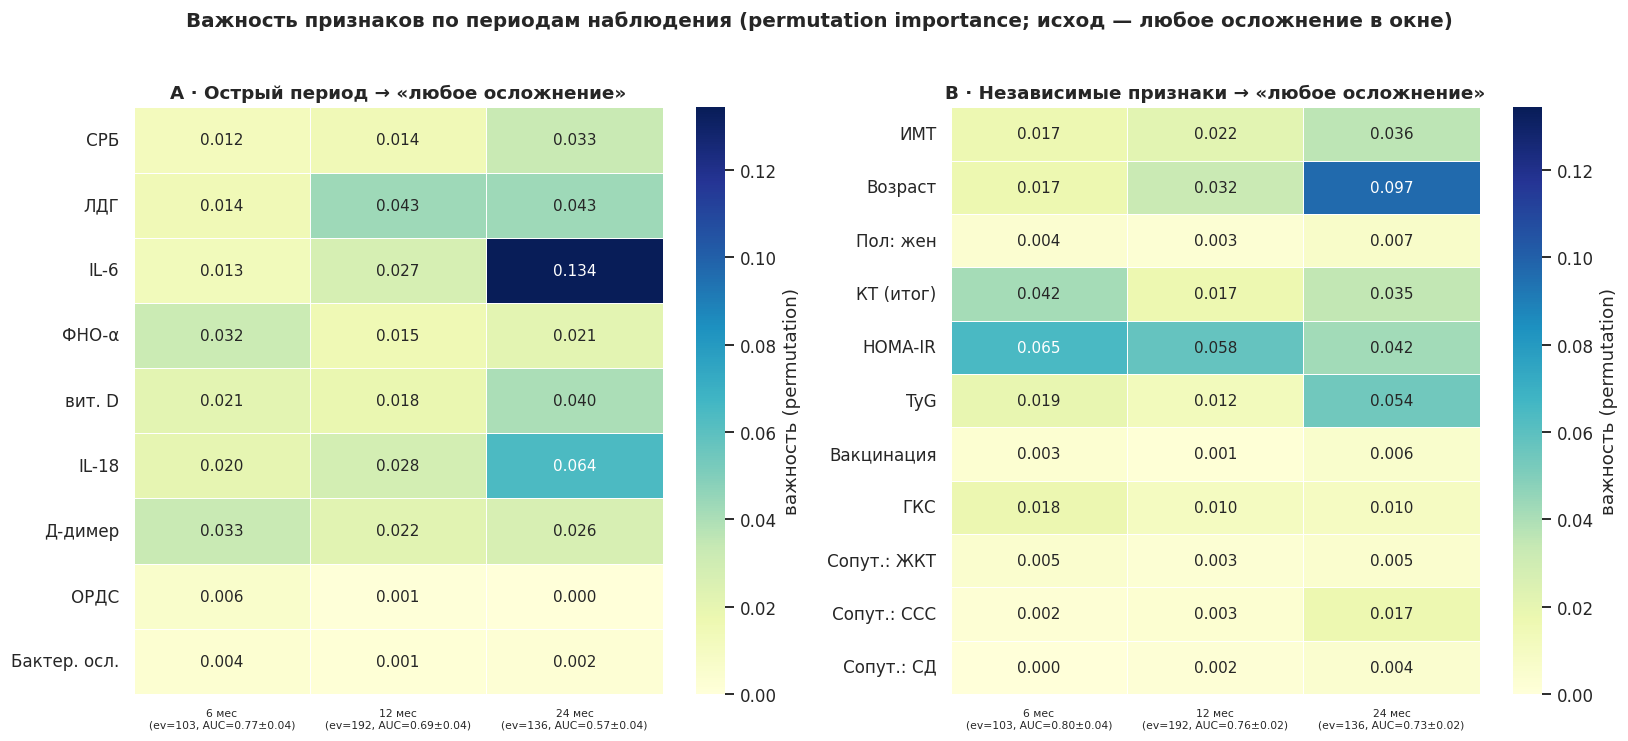

In [8]:
Ms = {}
for Xset, tag in [(XA, 'A'), (XB, 'B')]:
    M = pd.DataFrame(index=Xset.columns, dtype=float); au = {}
    for k, p in enumerate(PERIODS):
        y = comp_period('Любое осложнение', k)
        imp = rf_importance(Xset, y); au[p] = cv_auc(Xset, y)
        M[p] = imp.reindex(Xset.columns) if imp is not None else np.nan
    Ms[tag] = (M, au)
vmax_p = max(np.nanmax(Ms['A'][0].values), np.nanmax(Ms['B'][0].values))
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (tag, ttl) in zip(axes, [('A', 'A · Острый период'), ('B', 'B · Независимые признаки')]):
    M, au = Ms[tag]
    hdr = [f'{p}\n(ev={int(comp_period("Любое осложнение", k).sum())}, AUC={au[p][0]:.2f}±{au[p][1]:.2f})'
           for k, p in enumerate(PERIODS)]
    sns.heatmap(M.astype(float), annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=vmax_p, linewidths=0.5,
                mask=M.isna().values, cbar_kws={'label': 'важность (permutation)'}, ax=ax)
    ax.set_title(f'{ttl} → «любое осложнение»', fontweight='bold')
    ax.set_xticklabels(hdr, rotation=0, fontsize=7); ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Важность признаков по периодам наблюдения (permutation importance; исход — любое осложнение в окне)',
             y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
# таблица: ведущий признак (набор B) по каждой паре «осложнение × период»
rows = []
for cn in MODEL_COMPS:
    rec = {'Осложнение': cn}
    for k, p in enumerate(PERIODS):
        y = comp_period(cn, k); imp = rf_importance(XB, y)
        rec[p] = f'{imp.idxmax()} ({imp.max():.3f})' if imp is not None else '— (мало событий)'
    rows.append(rec)
print('Ведущий независимый признак (набор B, permutation importance) по периодам:')
display(pd.DataFrame(rows).set_index('Осложнение'))

Ведущий независимый признак (набор B, permutation importance) по периодам:


,6 мес,12 мес,24 мес
Осложнение,,,
Любое осложнение,HOMA-IR (0.065),HOMA-IR (0.058),Возраст (0.097)
ССЗ / АГ,HOMA-IR (0.065),Возраст (0.116),Сопут.: ССС (0.079)
Зрение / слух,HOMA-IR (0.046),Возраст (0.065),Возраст (0.070)
Рецидив. пневмонии,TyG (0.070),HOMA-IR (0.046),Возраст (0.196)
ЖКТ / МАЖБП,ИМТ (0.052),ГКС (0.068),TyG (0.081)
Психика / ЦНС,HOMA-IR (0.051),Возраст (0.125),Возраст (0.203)


**Как читать часть 1.** Набор независимых признаков (B) предсказывает осложнения существенно лучше
острых маркёров (A) — выше AUC почти для всех исходов. Ведущие независимые предикторы (по permutation
importance) — **HOMA-IR** (доминирует), **возраст, ИМТ, TyG** и **ГКС**; тяжесть КТ значима в однофакторном
OR (§1.1), но по многофакторной важности занимает средние позиции. Среди острых маркёров сильнее прочих —
**СРБ, ЛДГ, IL-6**. Профиль важности в целом устойчив по окнам 6/12/24; инцидентность осложнений в
объединённой выборке пиково в интервале до 12 месяцев.

---
# Часть 2. Учёт повторного COVID-19 по каждой нозологии

Повторный COVID-19 (65 пациентов) — потенциальный фактор поздних осложнений. Оцениваем его двумя способами:
(1) **распространённость** осложнений у переболевших повторно и однократно; (2) как **независимый признак**
в моделях по каждой нозологии.

## 2.1 Распространённость осложнений: повторный COVID vs однократный

,Повторный (n=65),Однократный (n=690)
Осложнение,,
Любое осложнение,100.0,42.3
ССЗ / АГ,30.8,13.6
Зрение / слух,43.1,17.7
Рецидив. пневмонии,70.8,18.6
ЖКТ / МАЖБП,53.8,23.3
Психика / ЦНС,24.6,9.3
Флеботромбоз,18.5,5.7
Пост. слабость,29.2,10.0
СД / эндокринные,10.8,5.1


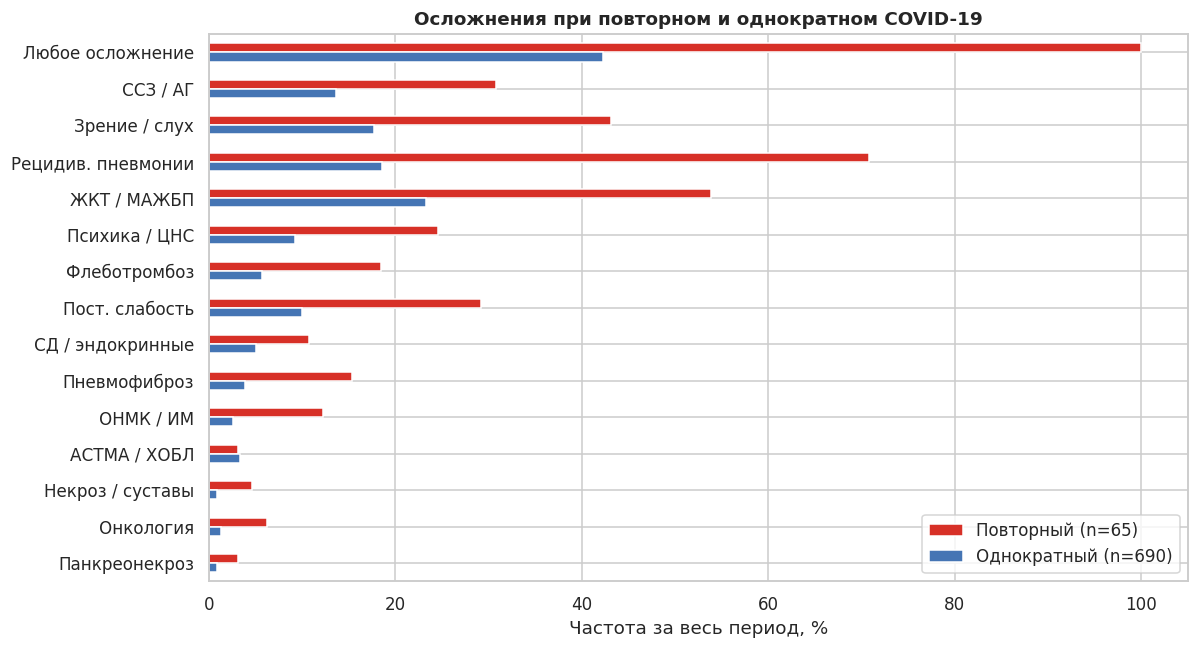

Замечание: при повторном COVID «любое осложнение» встречается у 100% — предиктор полностью разделяет этот исход, поэтому для «любого осложнения» приводится только частота, без OR.


In [10]:
rc = repeat_covid.values.astype(bool)
rows = []
for nm in ALL_TRIPLES:
    y = comp_any(nm).values
    rows.append({'Осложнение': nm,
                 'Повторный (n=%d)' % rc.sum(): 100 * y[rc].mean(),
                 'Однократный (n=%d)' % (~rc).sum(): 100 * y[~rc].mean()})
rcp = pd.DataFrame(rows).set_index('Осложнение').round(1)
display(rcp.map(lambda v: f'{v:.1f}'))

fig, ax = plt.subplots(figsize=(11, 6))
rcp.plot(kind='barh', ax=ax, color=['#d73027', '#4575b4'])
ax.set_xlabel('Частота за весь период, %'); ax.set_ylabel('')
ax.set_title('Осложнения при повторном и однократном COVID-19', fontweight='bold')
ax.legend(title=''); ax.invert_yaxis()
plt.tight_layout(); plt.show()
print('Замечание: при повторном COVID «любое осложнение» встречается у 100% — предиктор полностью разделяет '
      'этот исход, поэтому для «любого осложнения» приводится только частота, без OR.')

## 2.2 Повторный COVID как независимый фактор: скорректированное OR по нозологиям

Оцениваем **скорректированное (многофакторное) OR** повторного COVID: логистическая регрессия
`осложнение ~ повторный COVID + все независимые признаки` (возраст, ИМТ, КТ, HOMA-IR, TyG, пол,
вакцинация, ГКС, сопутствующие). Так учитываются различия групп (переболевшие повторно старше, с более
высокими ИМТ и HOMA-IR).

Скорректированное OR повторного COVID (— для «любого осложнения»: полное разделение, 100% исход):


,событий,aOR (повт. COVID),95% ДИ,p,знач.
Осложнение,,,,,
Любое осложнение,357,—,—,—,
ССЗ / АГ,114,2.06,1.02–4.17,0.045,*
Зрение / слух,150,2.98,1.58–5.62,<0.001,***
Рецидив. пневмонии,174,9.76,5.33–17.88,<0.001,***
ЖКТ / МАЖБП,196,2.78,1.47–5.25,0.002,**
Психика / ЦНС,80,2.78,1.39–5.56,0.004,**


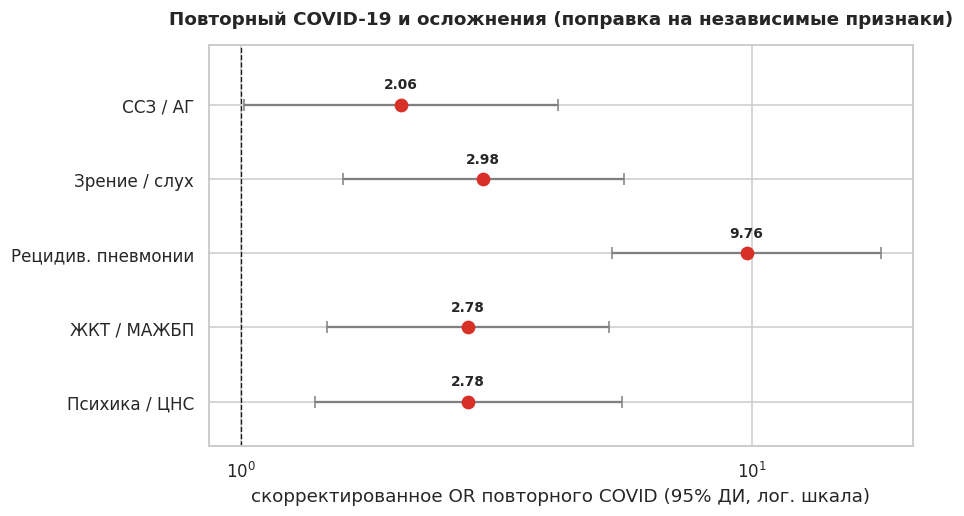

In [11]:
XB_rc = XB.copy(); XB_rc['Повторный COVID'] = repeat_covid
Xz = XB_rc.copy()
for c in CONT_B:                                   # стандартизуем непрерывные (OR на +1 SD)
    Xz[c] = (Xz[c] - Xz[c].mean()) / Xz[c].std()
rows = []
for nm in MODEL_COMPS:
    y = comp_any(nm); aor = lo = hi = p = np.nan
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')      # гасим ConvergenceWarning на «любом» (сепарация)
            r = sm.Logit(y, sm.add_constant(Xz)).fit(disp=0)
        b = 'Повторный COVID'; aor = np.exp(r.params[b])
        if np.isfinite(aor) and aor < 50:
            ci = np.exp(r.conf_int().loc[b]); lo, hi = ci.iloc[0], ci.iloc[1]; p = r.pvalues[b]
        else:
            aor = np.nan                            # полное разделение (напр. «любое осложнение»)
    except Exception:
        pass
    rows.append({'Осложнение': nm, 'событий': int(y.sum()), 'aOR (повт. COVID)': aor,
                 '95% ДИ': (f'{lo:.2f}–{hi:.2f}' if not pd.isna(aor) else '—'), 'lo': lo, 'hi': hi, 'p': p})
ordf = pd.DataFrame(rows)
disp = ordf.drop(columns=['lo', 'hi']).copy()
disp['знач.'] = disp['p'].map(stars)
disp['p'] = disp['p'].map(fmt_p)
disp['aOR (повт. COVID)'] = disp['aOR (повт. COVID)'].map(lambda o: '—' if pd.isna(o) else f'{o:.2f}')
print('Скорректированное OR повторного COVID (— для «любого осложнения»: полное разделение, 100% исход):')
display(disp.set_index('Осложнение'))

# forest — скорректированное OR с 95% ДИ
sub = ordf[ordf['aOR (повт. COVID)'].notna()].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
yp = np.arange(len(sub))[::-1]
ax.errorbar(sub['aOR (повт. COVID)'], yp,
            xerr=[sub['aOR (повт. COVID)'] - sub['lo'], sub['hi'] - sub['aOR (повт. COVID)']],
            fmt='o', color='#d73027', ecolor='gray', capsize=4, ms=8)
ax.axvline(1, color='k', ls='--', lw=0.9)
for y_, o in zip(yp, sub['aOR (повт. COVID)']):
    ax.text(o, y_ + 0.22, f'{o:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_yticks(yp); ax.set_yticklabels(sub['Осложнение'])
ax.set_ylim(-0.6, len(sub) - 0.2)
ax.set_xlabel('скорректированное OR повторного COVID (95% ДИ, лог. шкала)'); ax.set_xscale('log')
ax.set_title('Повторный COVID-19 и осложнения (поправка на независимые признаки)', fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

**Как читать часть 2.** Повторный COVID существенно связан с более частыми поздними осложнениями:
у переболевших повторно хотя бы одно осложнение встречается практически у всех (≈100% против ~42%), а по
отдельным нозологиям он остаётся **независимым** фактором риска (скорректированное OR > 1, значимо) даже
после поправки на возраст, ИМТ, метаболический фон и прочие признаки. Дизайн наблюдательный, а время
повторного эпизода относительно окон 6/12/24 не всегда известно — трактуем как ассоциацию.

---
# Часть 3. Осложнения по штаммам вируса: сравнение и предикторы

Анализируем распространённость осложнений и их предикторы **раздельно по геновариантам** (Ухань / Дельта /
Омикрон), сравниваем частоты между штаммами и по периодам, и определяем, какие признаки сильнее влияли на
осложнения при каждом штамме.

## 3.1 Распространённость осложнений по штаммам и периодам

Частота осложнения за весь период, % по штаммам (0.0 — осложнение не встречалось):


Штамм,Ухань,Дельта,Омикрон
Любое осложнение,44.6,50.7,45.9
ССЗ / АГ,13.6,12.5,18.9
Зрение / слух,23.9,27.2,9.3
Рецидив. пневмонии,22.1,23.9,23.0
ЖКТ / МАЖБП,26.3,29.0,22.6
Психика / ЦНС,12.7,13.2,6.3
Флеботромбоз,5.6,7.4,7.0
Пост. слабость,11.7,13.2,10.0
СД / эндокринные,6.6,7.0,3.3
Пневмофиброз,3.3,8.5,2.6


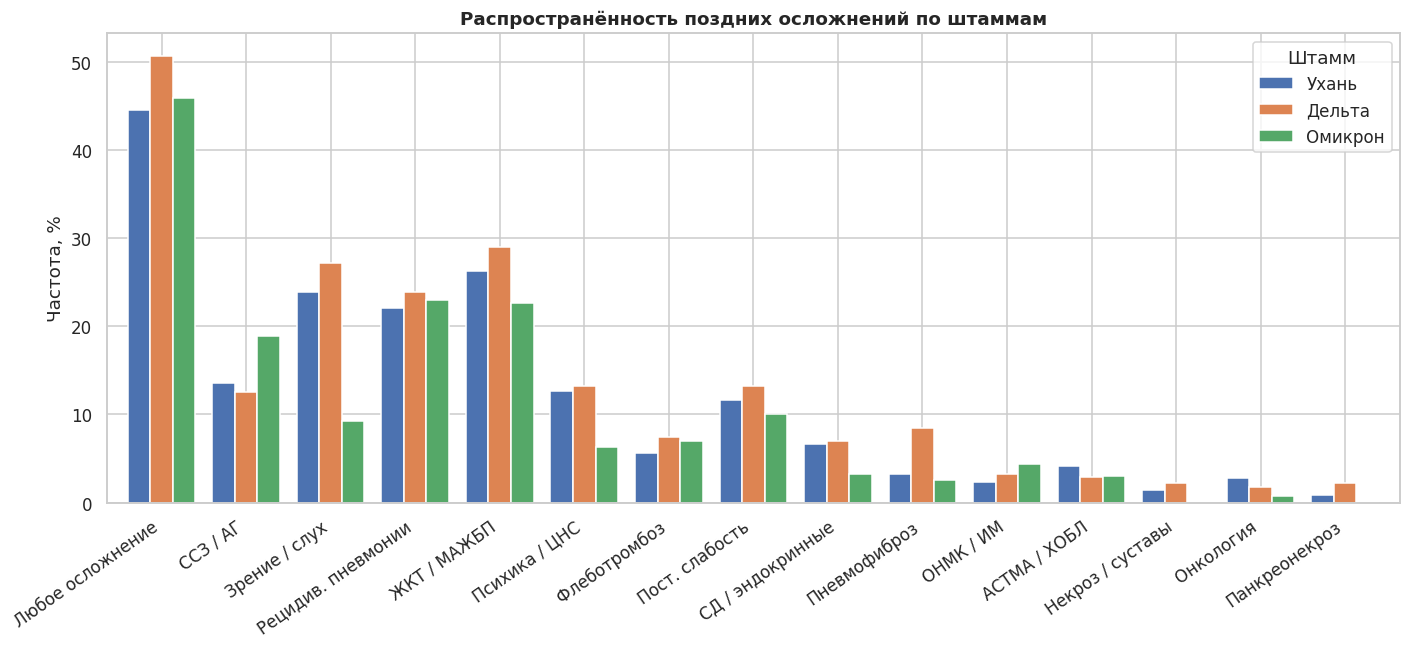

In [12]:
flags = pd.DataFrame({nm: comp_any(nm) for nm in ALL_TRIPLES})
flags['Штамм'] = G['Штамм'].values
prev_strain = (flags.groupby('Штамм', observed=True).mean() * 100).reindex(STRAINS).round(1)
print('Частота осложнения за весь период, % по штаммам (0.0 — осложнение не встречалось):')
display(prev_strain.T.map(lambda v: f'{v:.1f}'))

fig, ax = plt.subplots(figsize=(13, 6))
prev_strain.T.plot(kind='bar', ax=ax, color=[STRAIN_COLORS[s] for s in STRAINS], width=0.8)
ax.set_ylabel('Частота, %'); ax.set_xlabel('')
ax.set_title('Распространённость поздних осложнений по штаммам', fontweight='bold')
ax.legend(title='Штамм'); plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

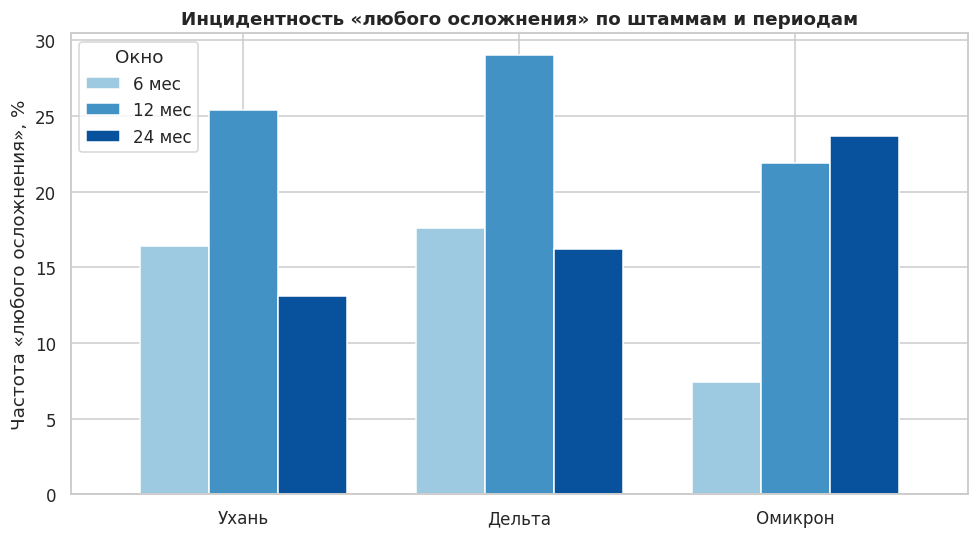

,6 мес,12 мес,24 мес
Штамм,,,
Ухань,16.4,25.4,13.1
Дельта,17.6,29.0,16.2
Омикрон,7.4,21.9,23.7


In [13]:
# распространённость «любого осложнения» по штаммам × период
rows = []
for s in STRAINS:
    m = (G.Штамм == s).values
    rows.append({'Штамм': s, **{p: 100 * comp_period('Любое осложнение', k)[m].mean() for k, p in enumerate(PERIODS)}})
sp = pd.DataFrame(rows).set_index('Штамм').round(1)
fig, ax = plt.subplots(figsize=(9, 5))
sp.plot(kind='bar', ax=ax, color=[PERIOD_COLORS[p] for p in PERIODS], width=0.75)
ax.set_ylabel('Частота «любого осложнения», %'); ax.set_xlabel('')
ax.set_title('Инцидентность «любого осложнения» по штаммам и периодам', fontweight='bold')
ax.legend(title='Окно'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
display(sp.map(lambda v: f'{v:.1f}'))

## 3.2 Различия частоты между штаммами (χ² + FDR)

In [14]:
rows = []
for nm in ALL_TRIPLES:
    ct = pd.crosstab(G['Штамм'], comp_any(nm))
    if ct.shape[1] < 2:
        continue
    chi2, p, dof, exp = chi2_contingency(ct)
    rows.append([nm, round(chi2, 2), p, round(exp.min(), 1)])
chi = pd.DataFrame(rows, columns=['Осложнение', 'χ²', 'p', 'min ожид.'])
# FDR только по надёжным тестам (min ожид. >= 5); разреженные — вне пула, помечаются
valid = chi['min ожид.'] >= 5
chi['q (FDR)'] = np.nan
chi.loc[valid, 'q (FDR)'] = multipletests(chi.loc[valid, 'p'], method='fdr_bh')[1]
chi['вывод'] = np.where(~valid, 'мало данных (не в FDR)',
                        np.where(chi['q (FDR)'] < 0.05, 'значимо', 'поисково'))
chi['p'] = chi['p'].map(fmt_p); chi['q (FDR)'] = chi['q (FDR)'].map(fmt_p)
print('Различия частоты между штаммами. Нозологии с min ожид. < 5 исключены из FDR-пула (χ² ненадёжен):')
display(chi.sort_values('Осложнение').reset_index(drop=True))

Различия частоты между штаммами. Нозологии с min ожид. < 5 исключены из FDR-пула (χ² ненадёжен):


,Осложнение,χ²,p,min ожид.,q (FDR),вывод
0,АСТМА / ХОБЛ,0.770,0.679,7.100,0.803,поисково
1,ЖКТ / МАЖБП,2.950,0.229,55.300,0.457,поисково
2,Зрение / слух,30.510,<0.001,42.300,<0.001,значимо
3,Любое осложнение,2.110,0.347,100.700,0.595,поисково
4,Некроз / суставы,5.720,0.057,2.500,—,мало данных (не в FDR)
5,ОНМК / ИМ,1.600,0.450,7.300,0.669,поисково
6,Онкология,3.070,0.216,3.700,—,мало данных (не в FDR)
7,Панкреонекроз,6.330,0.042,2.300,—,мало данных (не в FDR)
8,Пневмофиброз,11.650,0.003,10.400,0.018,значимо
9,Пост. слабость,1.380,0.502,24.800,0.669,поисково


## 3.3 Предикторы осложнений внутри каждого штамма (permutation importance)

Для каждого штамма отдельно — важность независимых признаков (набор B) для «любого осложнения», что
показывает, какие факторы сильнее влияли на осложнение при данном геноварианте.

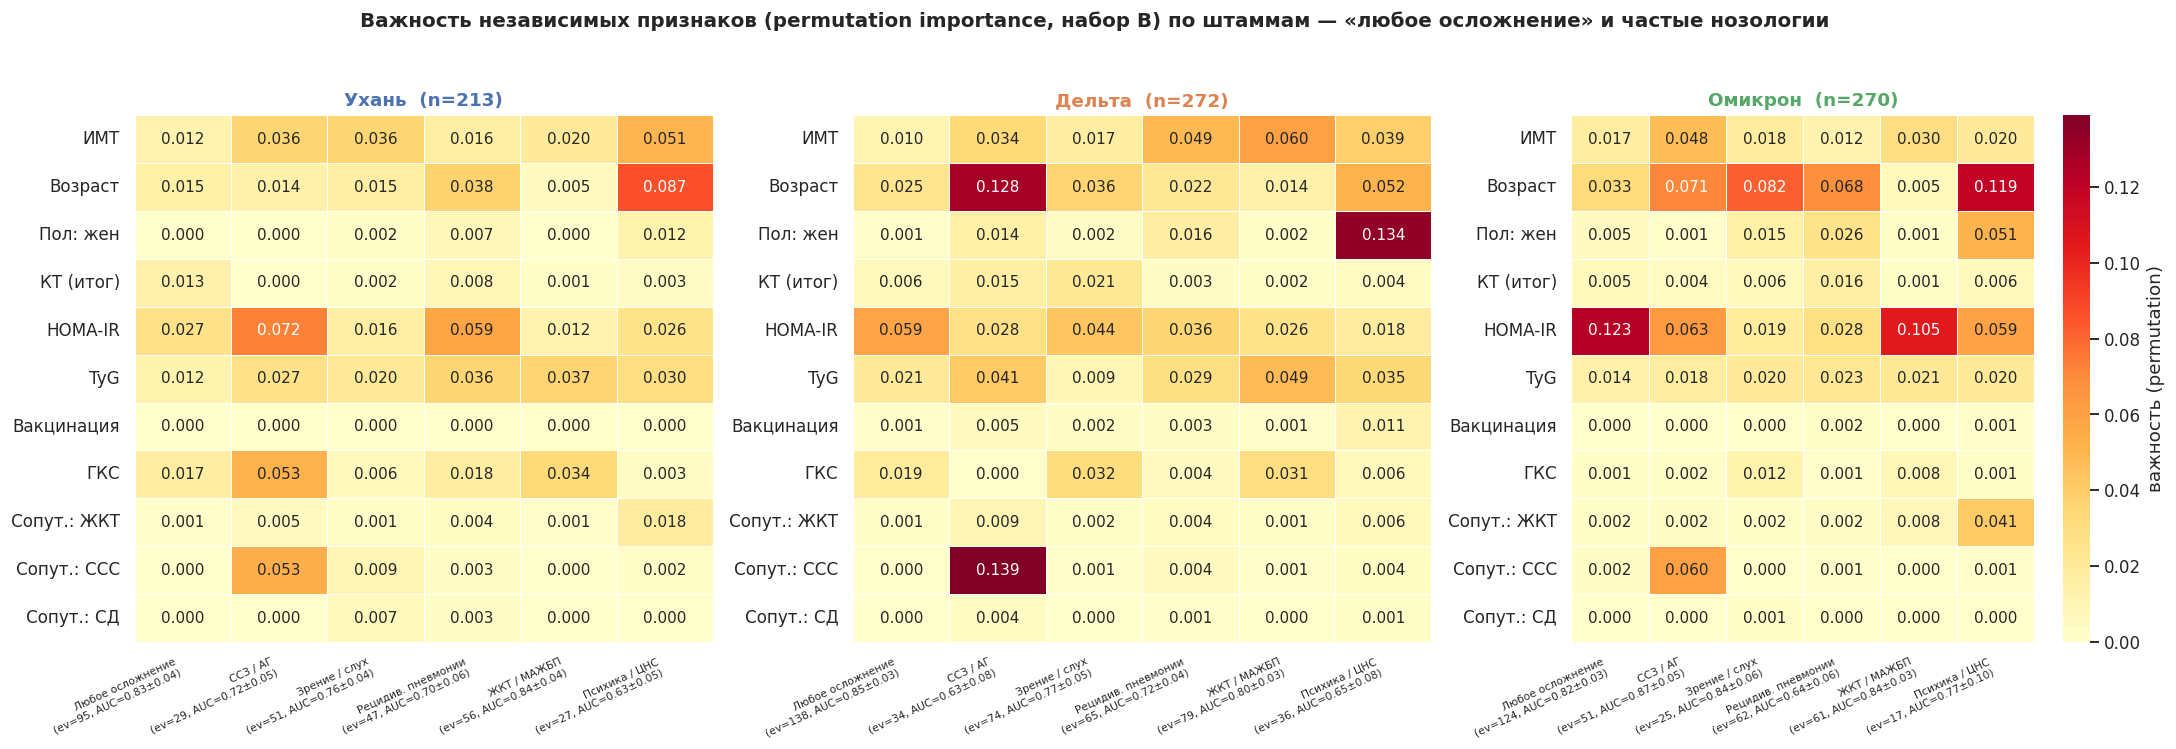

Ведущие независимые признаки «любого осложнения» по штаммам (permutation importance):


,1-й,2-й,3-й
Штамм,,,
Ухань,HOMA-IR (0.027),ГКС (0.017),Возраст (0.015)
Дельта,HOMA-IR (0.059),Возраст (0.025),TyG (0.021)
Омикрон,HOMA-IR (0.123),Возраст (0.033),ИМТ (0.017)


In [15]:
strain_imp = {}
for s in STRAINS:
    m = (G.Штамм == s).values; Xs = XB[m]
    IMP = pd.DataFrame(index=XB.columns, dtype=float); au = {}
    for cn in MODEL_COMPS:
        y = comp_any(cn).values[m]
        imp = rf_importance(Xs, y); au[cn] = cv_auc(Xs, y)
        IMP[cn] = imp.reindex(XB.columns) if imp is not None else np.nan
    strain_imp[s] = (IMP, au)
vmax_s = max(np.nanmax(strain_imp[s][0].values) for s in STRAINS)
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
for ax, s in zip(axes, STRAINS):
    m = (G.Штамм == s).values; IMP, au = strain_imp[s]
    hdr = [f'{cn}\n(ev={int(comp_any(cn).values[m].sum())}, AUC={au[cn][0]:.2f}±{au[cn][1]:.2f})' for cn in MODEL_COMPS]
    sns.heatmap(IMP.astype(float), annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=vmax_s, linewidths=0.5,
                mask=IMP.isna().values, cbar=(s == STRAINS[-1]), cbar_kws={'label': 'важность (permutation)'}, ax=ax)
    ax.set_facecolor('#EDEDED')
    ax.set_title(f'{s}  (n={int(m.sum())})', fontweight='bold', color=STRAIN_COLORS[s])
    ax.set_xticklabels(hdr, rotation=25, ha='right', fontsize=7); ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Важность независимых признаков (permutation importance, набор B) по штаммам — «любое осложнение» и частые нозологии',
             y=1.04, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ведущий признак по каждому штамму (любое осложнение)
rows = []
for s in STRAINS:
    m = (G.Штамм == s).values
    imp = rf_importance(XB[m], comp_any('Любое осложнение').values[m])
    if imp is None:
        rows.append({'Штамм': s, '1-й': '— (мало событий)', '2-й': '', '3-й': ''}); continue
    top = imp.sort_values(ascending=False)
    rows.append({'Штамм': s, '1-й': f'{top.index[0]} ({top.iloc[0]:.3f})',
                 '2-й': f'{top.index[1]} ({top.iloc[1]:.3f})', '3-й': f'{top.index[2]} ({top.iloc[2]:.3f})'})
print('Ведущие независимые признаки «любого осложнения» по штаммам (permutation importance):')
display(pd.DataFrame(rows).set_index('Штамм'))

**Как читать часть 3.** Частоты осложнений различаются между штаммами (см. χ² + FDR); ядро предикторов
(**HOMA-IR, возраст, ИМТ, TyG**) воспроизводится во всех геновариантах, но их относительный вклад смещается.
Различия частично объясняются составом групп (возраст, вакцинация, тяжесть) — трактуются с осторожностью.

---
# Часть 4. SHAP-разбор независимых признаков по штаммам и месяцам

**SHAP** объясняет вклад каждого независимого признака в предсказание осложнения. Приводим: (1) среднюю
важность |SHAP| по штаммам и (2) по периодам для «любого осложнения», и (3) waterfall-разбор
репрезентативного пациента для каждого штамма.

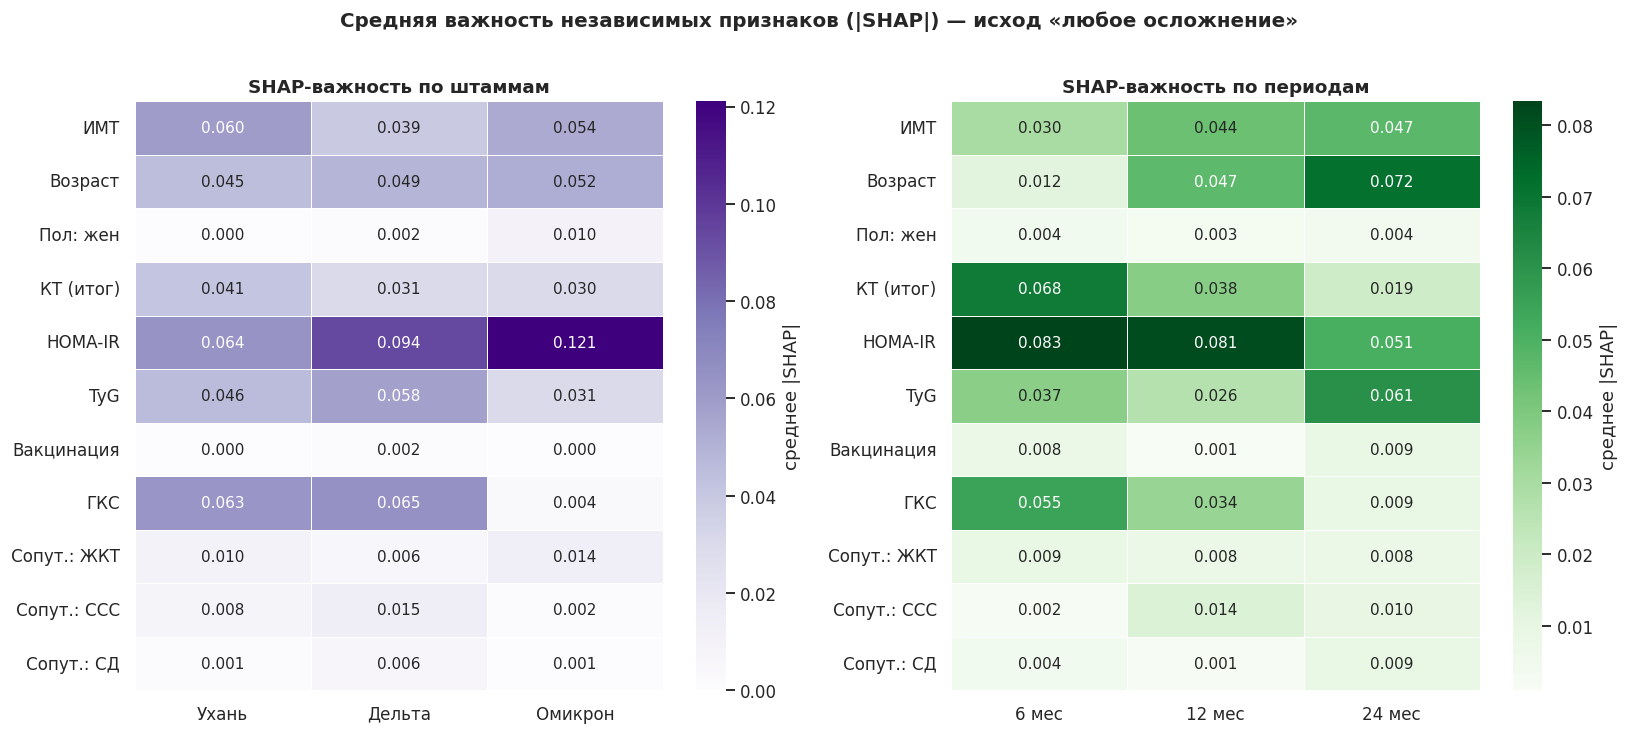

In [16]:
import shap

def shap_matrix(splits, label):
    """Средний |SHAP| по признакам B для каждого среза (штамм или период)."""
    M = pd.DataFrame(index=XB.columns, dtype=float)
    for name, (X, y) in splits.items():
        y = np.asarray(y)
        if y.sum() < 12 or (len(y) - y.sum()) < 12:
            M[name] = np.nan; continue
        rf = rf_new(200).fit(X, y)
        sv = shap.TreeExplainer(rf).shap_values(X, check_additivity=False)
        arr = np.array(sv)
        if arr.ndim == 3:
            vals = arr[:, :, 1] if arr.shape[-1] == 2 else (arr[1] if arr.shape[0] == 2 else arr[..., -1])
        elif isinstance(sv, list):
            vals = np.array(sv[1])
        else:
            vals = arr
        M[name] = np.abs(vals).mean(axis=0)
    return M

y_any = comp_any('Любое осложнение')
strain_splits = {s: (XB[(G.Штамм == s).values], y_any.values[(G.Штамм == s).values]) for s in STRAINS}
period_splits = {p: (XB, comp_period('Любое осложнение', k)) for k, p in enumerate(PERIODS)}
Ms = shap_matrix(strain_splits, 'штамм')
Mp = shap_matrix(period_splits, 'период')

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
sns.heatmap(Ms.astype(float), annot=True, fmt='.3f', cmap='Purples', linewidths=0.5, ax=axes[0],
            mask=Ms.isna().values, cbar_kws={'label': 'среднее |SHAP|'})
axes[0].set_title('SHAP-важность по штаммам', fontweight='bold')
sns.heatmap(Mp.astype(float), annot=True, fmt='.3f', cmap='Greens', linewidths=0.5, ax=axes[1],
            mask=Mp.isna().values, cbar_kws={'label': 'среднее |SHAP|'})
axes[1].set_title('SHAP-важность по периодам', fontweight='bold')
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0); ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle('Средняя важность независимых признаков (|SHAP|) — исход «любое осложнение»', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4.2 Waterfall-разбор репрезентативного пациента по штаммам

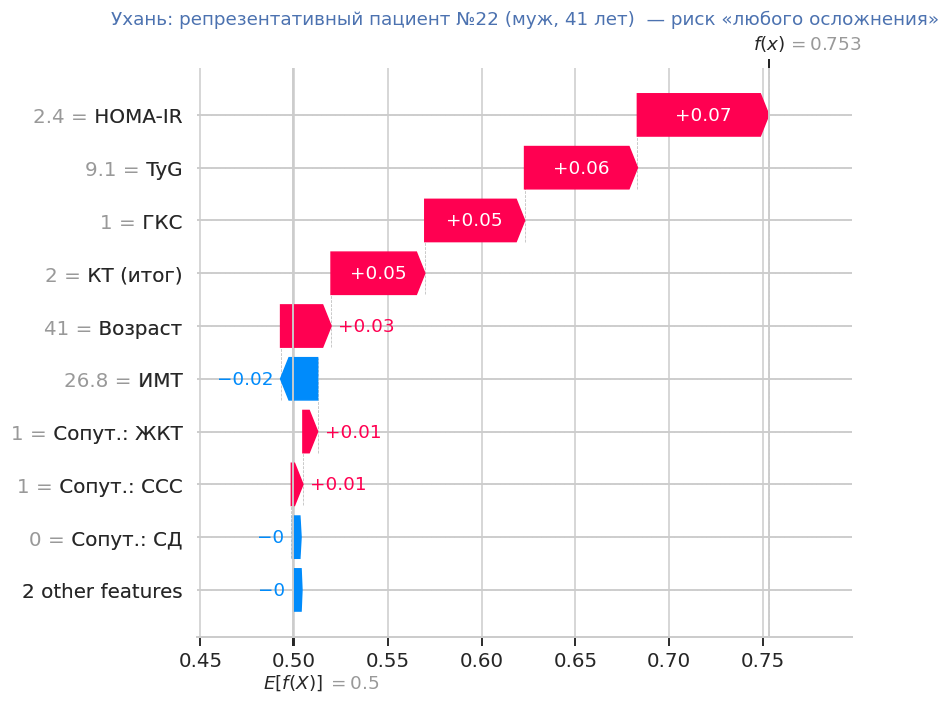

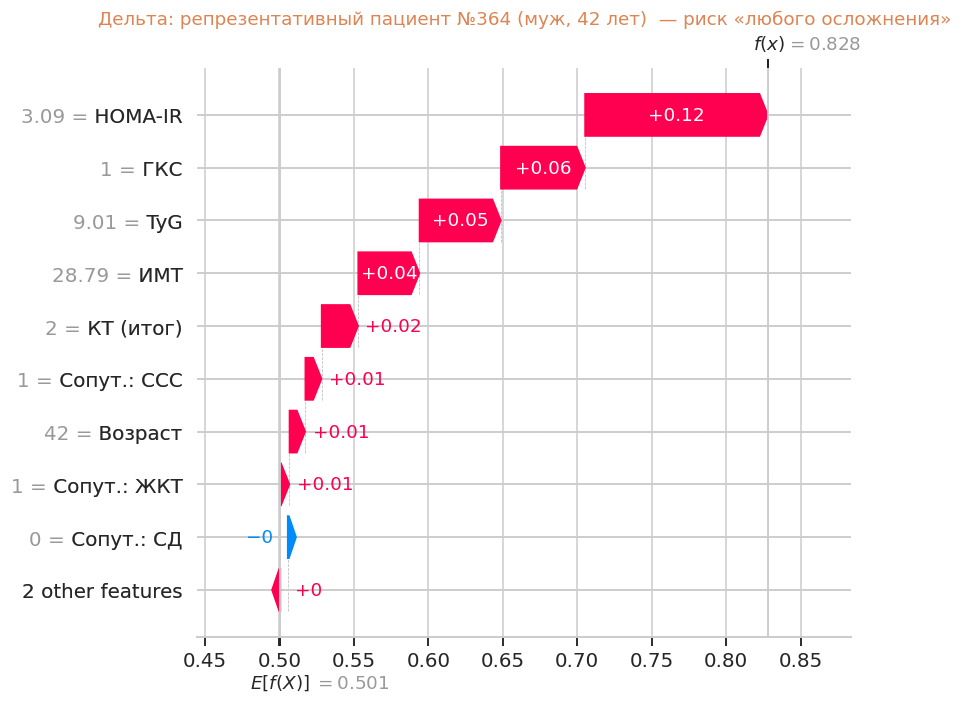

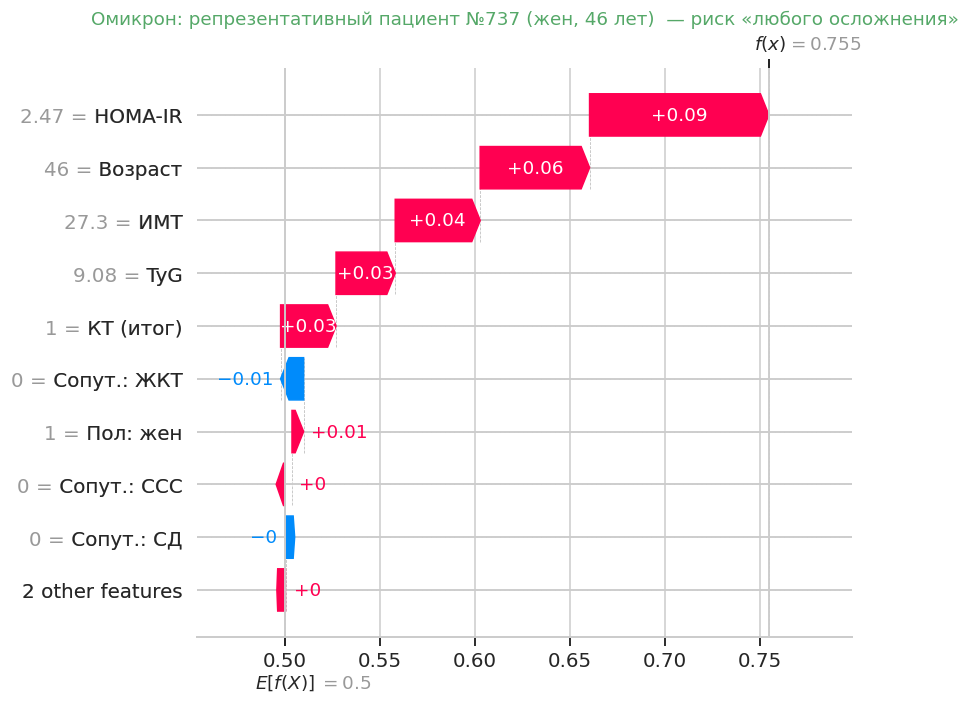

In [17]:
iqr = (XB.quantile(0.75) - XB.quantile(0.25)).replace(0, 1.0)
zXB = (XB - XB.median()) / iqr

def representative(y, idxpool):
    pos = idxpool[y.values[idxpool] == 1]
    if len(pos) == 0:
        return None
    centroid = zXB.iloc[pos].mean()
    dist = ((zXB.iloc[pos] - centroid) ** 2).sum(axis=1)
    return dist.idxmin()

# waterfall строим отдельными фигурами на штамм: shap.plots.waterfall плохо совмещается в subplots
for s in STRAINS:
    m = np.where((G.Штамм == s).values)[0]
    Xs, ys = XB.iloc[m], comp_any('Любое осложнение').iloc[m]
    rf = rf_new(300).fit(Xs, ys)
    ridx = representative(comp_any('Любое осложнение'), m)
    expl_obj = shap.TreeExplainer(rf)
    sv = expl_obj.shap_values(XB.loc[[ridx]], check_additivity=False)
    arr = np.array(sv)
    if arr.ndim == 3:
        vals = arr[0, :, 1] if arr.shape[-1] == 2 else arr[1, 0, :]
    elif isinstance(sv, list):
        vals = np.array(sv[1])[0]
    else:
        vals = arr[0]
    ev = expl_obj.expected_value
    base = float(ev[1]) if hasattr(ev, '__len__') else float(ev)
    plt.figure(figsize=(10, 5.5))
    expl = shap.Explanation(values=np.asarray(vals, float), base_values=base,
                            data=XB.loc[ridx].values, feature_names=list(XB.columns))
    shap.plots.waterfall(expl, max_display=10, show=False)
    age = int(col(2).loc[ridx]); sex = 'жен' if col(3).loc[ridx] == 2 else 'муж'
    plt.title(f'{s}: репрезентативный пациент №{ridx} ({sex}, {age} лет)  — риск «любого осложнения»',
              fontsize=12, color=STRAIN_COLORS[s])
    plt.tight_layout(); plt.show()

**Как читать часть 4.** SHAP согласуется с permutation importance: наибольший вклад в риск «любого
осложнения» вносит **HOMA-IR** (доминирует во всех штаммах), затем **возраст, ИМТ, TyG** и **ГКС**;
тяжесть КТ по SHAP занимает средние позиции (заметна в раннем окне 6 мес). Относительный вес признаков
смещается между штаммами и периодами. Waterfall показывает логику модели на конкретном репрезентативном
пациенте каждого штамма (красное — повышает риск, синее — снижает).

---
# Часть 5. Детальные предикторы по отдельным нозологиям (независимые признаки)

По запросу — расширенный разбор предикторов для клинически значимых осложнений: **рецидивирующие
пневмонии, ССЗ/АГ, СД, флеботромбоз** — раздельно **по штаммам и периодам**; **ОНМК/ИМ** — общий (все
штаммы), только по периодам. Признаки — только **независимые** (набор B). Важность — permutation importance.

Для каждой нозологии: (1) **диаграмма инцидентности** по штаммам и окнам 6/12/24; (2) **тепловая карта
важности** признаков — панели по штаммам плюс «Все штаммы» (укрупнённо по периодам). Ячейки с **< 12
событиями оставлены пустыми** — на таком числе оценка важности недостоверна (особенно для редких СД,
флеботромбоза, ОНМК/ИМ, где деление по штамм×период почти всюду недостаточно обеспечено).

In [18]:
# облегчённые версии для мелких срезов штамм×период (меньше деревьев/повторов — ради скорости)
def _cv_light(X, y):
    y = np.asarray(y)
    if y.sum() < 12 or (len(y) - y.sum()) < 12:
        return np.nan, np.nan
    try:
        sc = cross_val_score(rf_new(200), X, y, scoring='roc_auc',
                             cv=RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=RANDOM_STATE))
        return sc.mean(), sc.std()
    except Exception:
        return np.nan, np.nan

def _imp_light(X, y):
    y = np.asarray(y)
    if y.sum() < 12 or (len(y) - y.sum()) < 12:
        return None
    rf = rf_new(200); rf.fit(X, y); rf.n_jobs = 1
    pi = permutation_importance(rf, X, y, scoring='roc_auc', n_repeats=6, random_state=RANDOM_STATE, n_jobs=-1)
    return pd.Series(np.clip(pi.importances_mean, 0, None), index=X.columns)

def detail_incidence(name, by_strain=True):
    if by_strain:
        d = pd.DataFrame([{'Штамм': s, **{PERIODS[k]: 100 * comp_period(name, k)[(G.Штамм == s).values].mean()
                                          for k in range(3)}} for s in STRAINS]).set_index('Штамм')
        fig, ax = plt.subplots(figsize=(9, 4.6))
        d.plot(kind='bar', ax=ax, color=[PERIOD_COLORS[p] for p in PERIODS], width=0.75)
        ax.set_title(f'Инцидентность: {name} — по штаммам и периодам', fontweight='bold')
        ax.legend(title='Окно'); plt.xticks(rotation=0)
    else:
        d = pd.Series({PERIODS[k]: 100 * comp_period(name, k).mean() for k in range(3)})
        fig, ax = plt.subplots(figsize=(6, 4))
        d.plot(kind='bar', ax=ax, color=[PERIOD_COLORS[p] for p in PERIODS], width=0.6)
        ax.set_title(f'Инцидентность: {name} — по периодам (все штаммы)', fontweight='bold')
        plt.xticks(rotation=0)
    ax.set_ylabel('инцидентность, %'); ax.set_xlabel('')
    plt.tight_layout(); plt.show()

def detail_importance(name, by_strain=True):
    panels = (STRAINS + ['Все штаммы']) if by_strain else ['Все штаммы']
    data = {}
    for pan in panels:
        m = (G.Штамм == pan).values if pan in STRAINS else np.ones(len(G), bool)
        IMP = pd.DataFrame(index=XB.columns, dtype=float); hdr = []
        for k in range(3):
            y = comp_period(name, k).values[m]; Xsub = XB[m]
            m_auc, s_auc = _cv_light(Xsub, y)
            reliable = (not np.isnan(m_auc)) and (m_auc - s_auc > 0.5)   # нижняя граница AUC выше случайной
            imp = _imp_light(Xsub, y) if reliable else None
            IMP[PERIODS[k]] = imp.reindex(XB.columns) if imp is not None else np.nan
            au = f'{m_auc:.2f}±{s_auc:.2f}' if not np.isnan(m_auc) else '—'
            hdr.append(f'{PERIODS[k]}\n(ev={int(y.sum())}, AUC={au})')
        data[pan] = (IMP, hdr)
    vals = [np.nanmax(data[p][0].values) for p in panels if not np.all(np.isnan(data[p][0].values))]
    vmax = max(vals) if vals else 0.1
    fig, axes = plt.subplots(1, len(panels), figsize=(5.4 * len(panels), 6.3))
    if len(panels) == 1:
        axes = [axes]
    for ax, pan in zip(axes, panels):
        IMP, hdr = data[pan]
        sns.heatmap(IMP.astype(float), annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=vmax, linewidths=0.5,
                    mask=IMP.isna().values, cbar=(pan == panels[-1]), cbar_kws={'label': 'важность (permutation)'}, ax=ax)
        ax.set_facecolor('#EDEDED')
        n_ = int((G.Штамм == pan).sum()) if pan in STRAINS else len(G)
        ax.set_title(f'{pan} (n={n_})', fontweight='bold', color=STRAIN_COLORS.get(pan, '#333333'))
        ax.set_xticklabels(hdr, rotation=0, fontsize=7)
        if ax is axes[0]:
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        else:
            ax.set_yticklabels([]); ax.set_ylabel('')
    scope = 'по штаммам × периодам' if by_strain else 'по периодам (все штаммы)'
    note = ('(пустые ячейки — < 12 событий; «Все штаммы» — укрупнённо по периодам)'
            if by_strain else '(пустые ячейки — < 12 событий)')
    fig.suptitle(f'Важность независимых признаков (permutation) — {name}: {scope}\n{note}',
                 y=1.05, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
print('OK')

OK


## 5.1 Рецидивирующие пневмонии — по штаммам и периодам

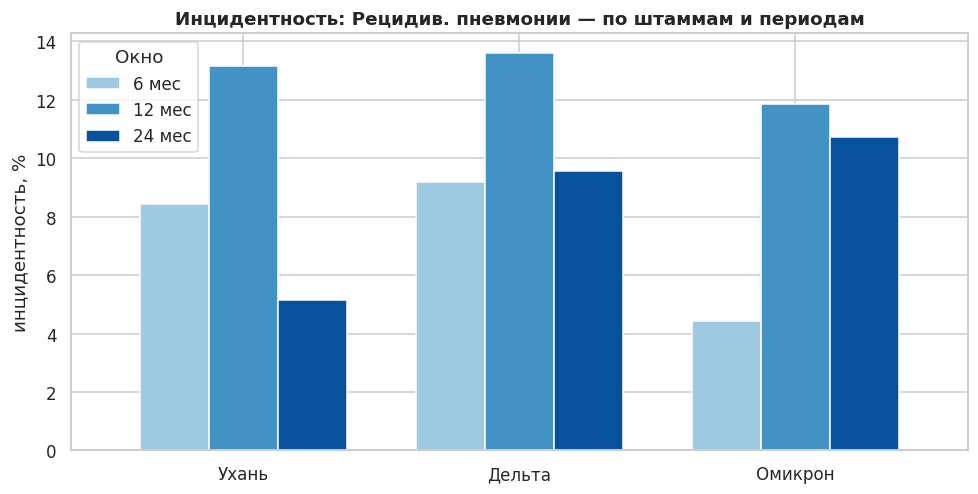

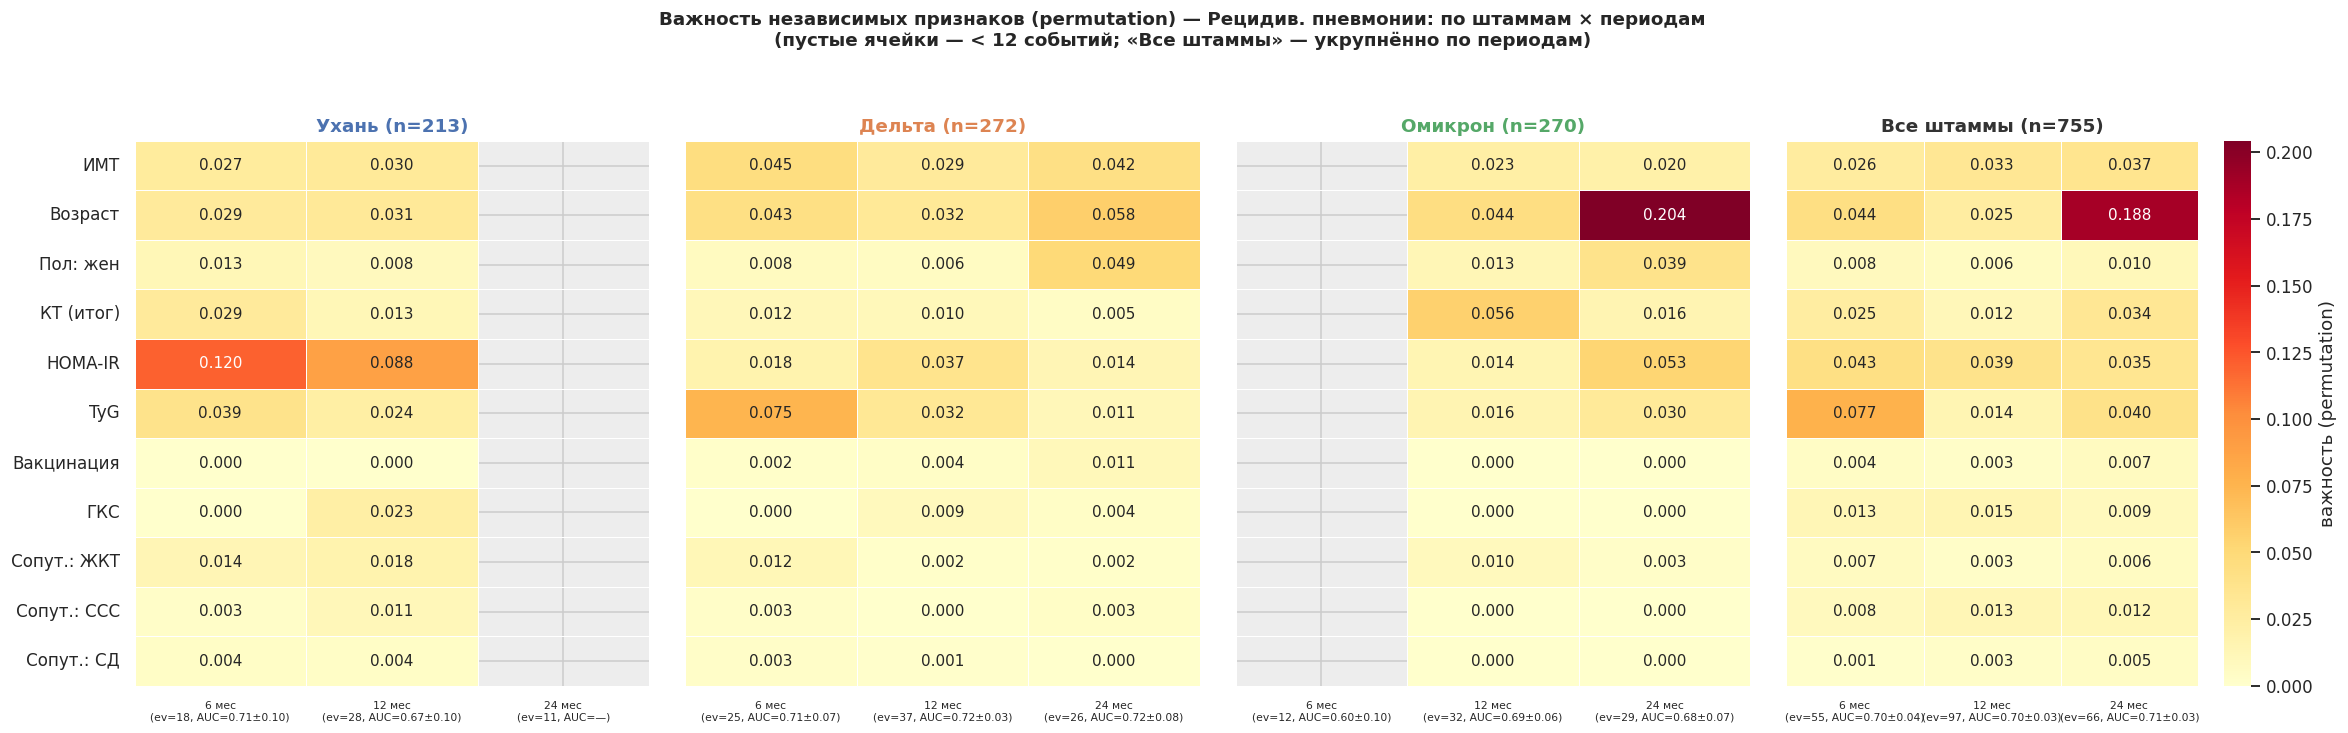

In [19]:
detail_incidence('Рецидив. пневмонии', by_strain=True)
detail_importance('Рецидив. пневмонии', by_strain=True)

## 5.2 ССЗ / АГ — по штаммам и периодам

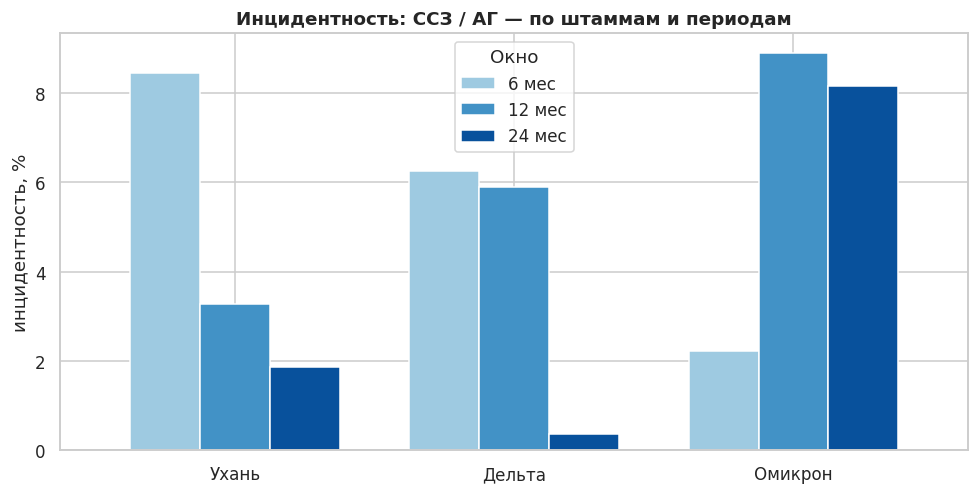

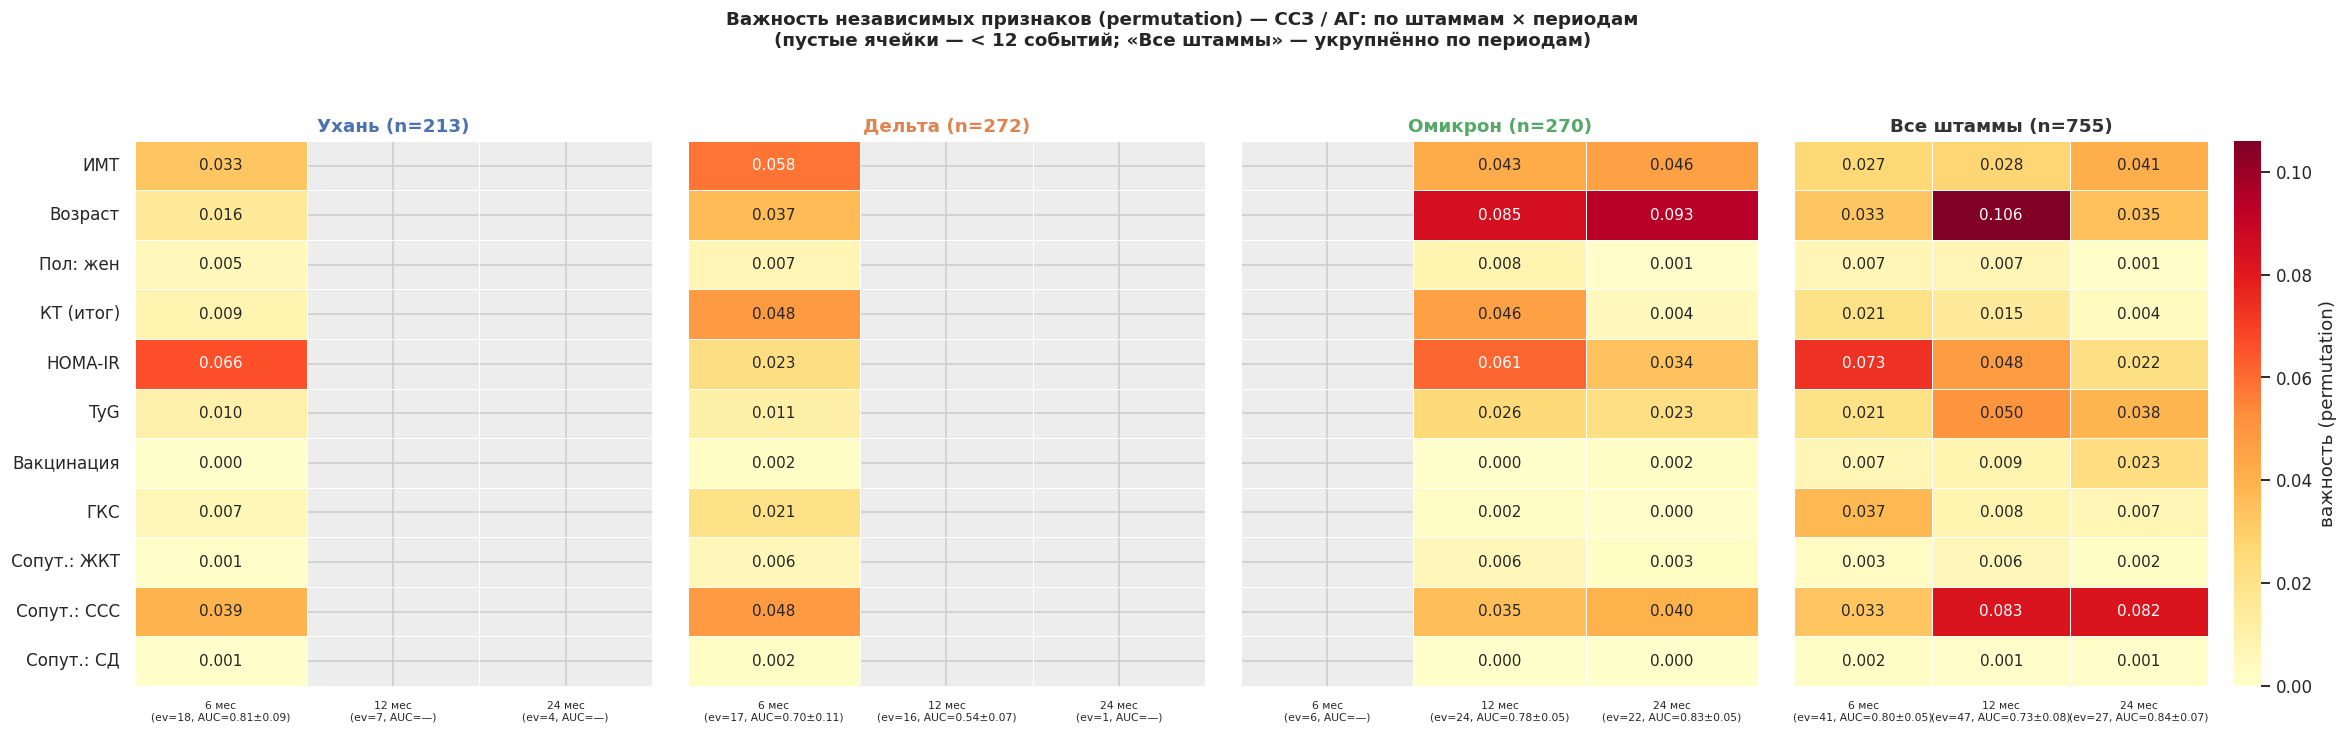

In [20]:
detail_incidence('ССЗ / АГ', by_strain=True)
detail_importance('ССЗ / АГ', by_strain=True)

## 5.3 СД / эндокринные — по штаммам и периодам

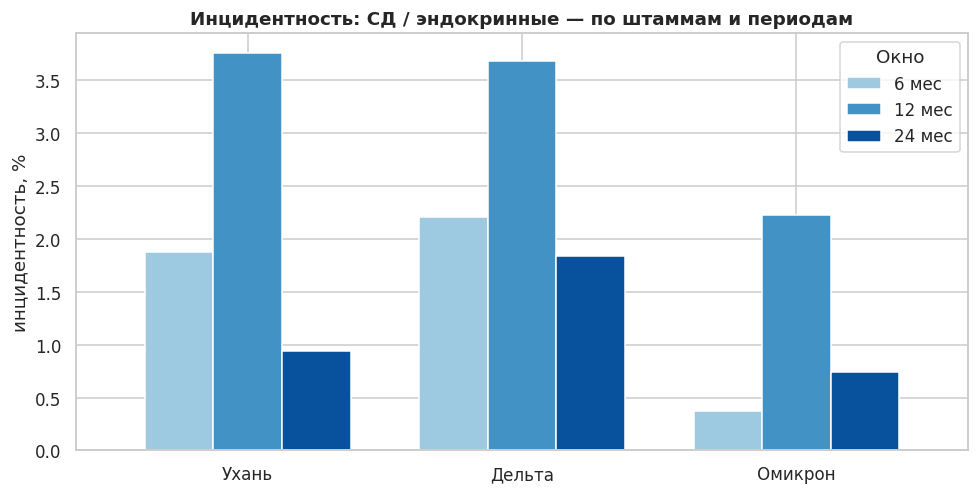

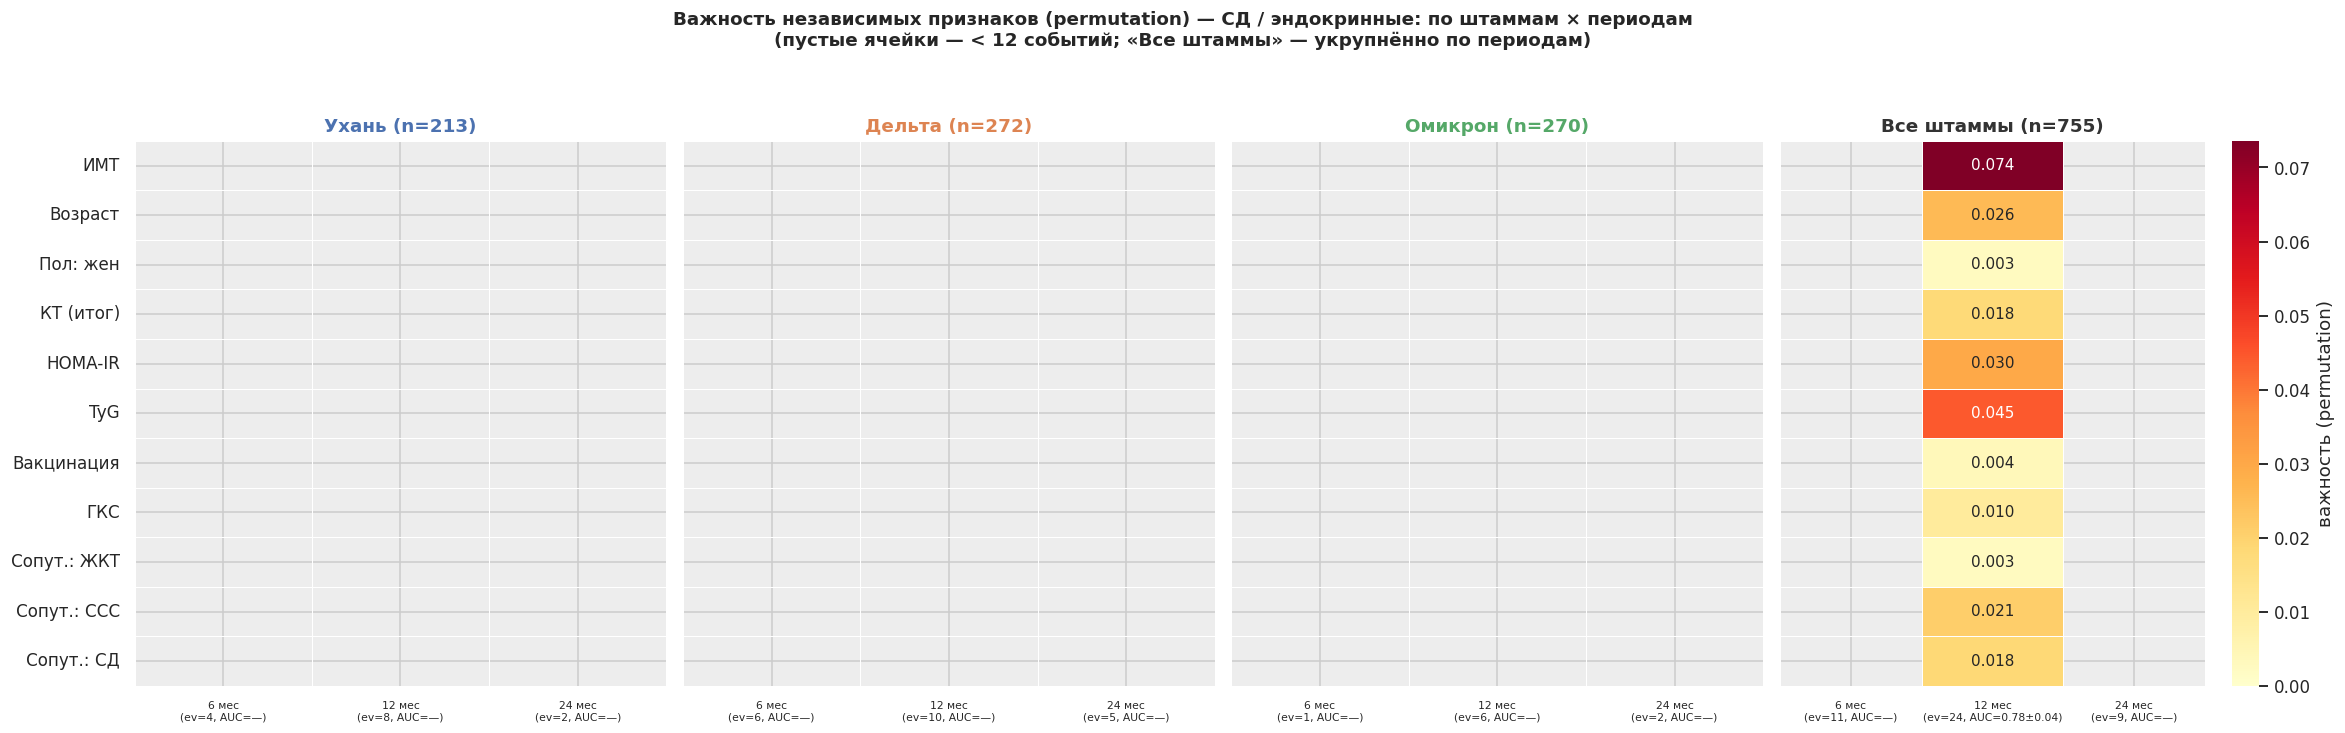

In [21]:
detail_incidence('СД / эндокринные', by_strain=True)
detail_importance('СД / эндокринные', by_strain=True)

## 5.4 Флеботромбоз — по штаммам и периодам

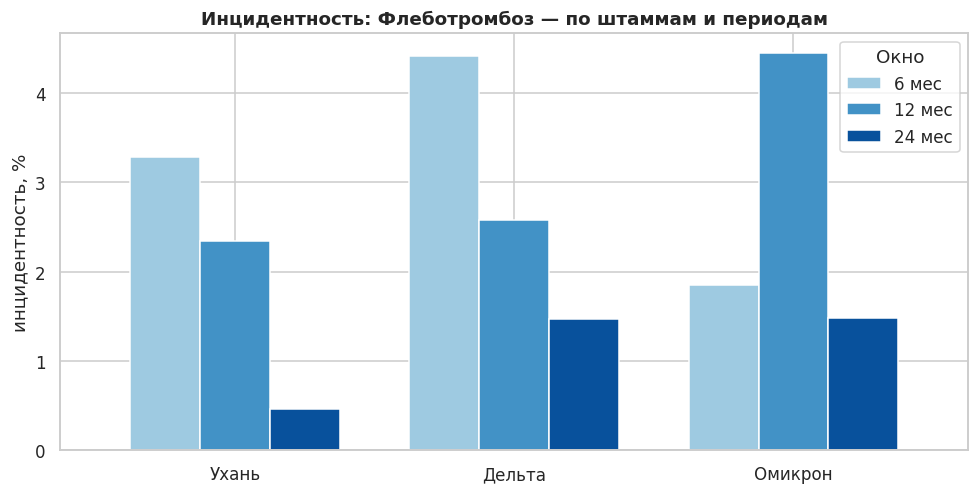

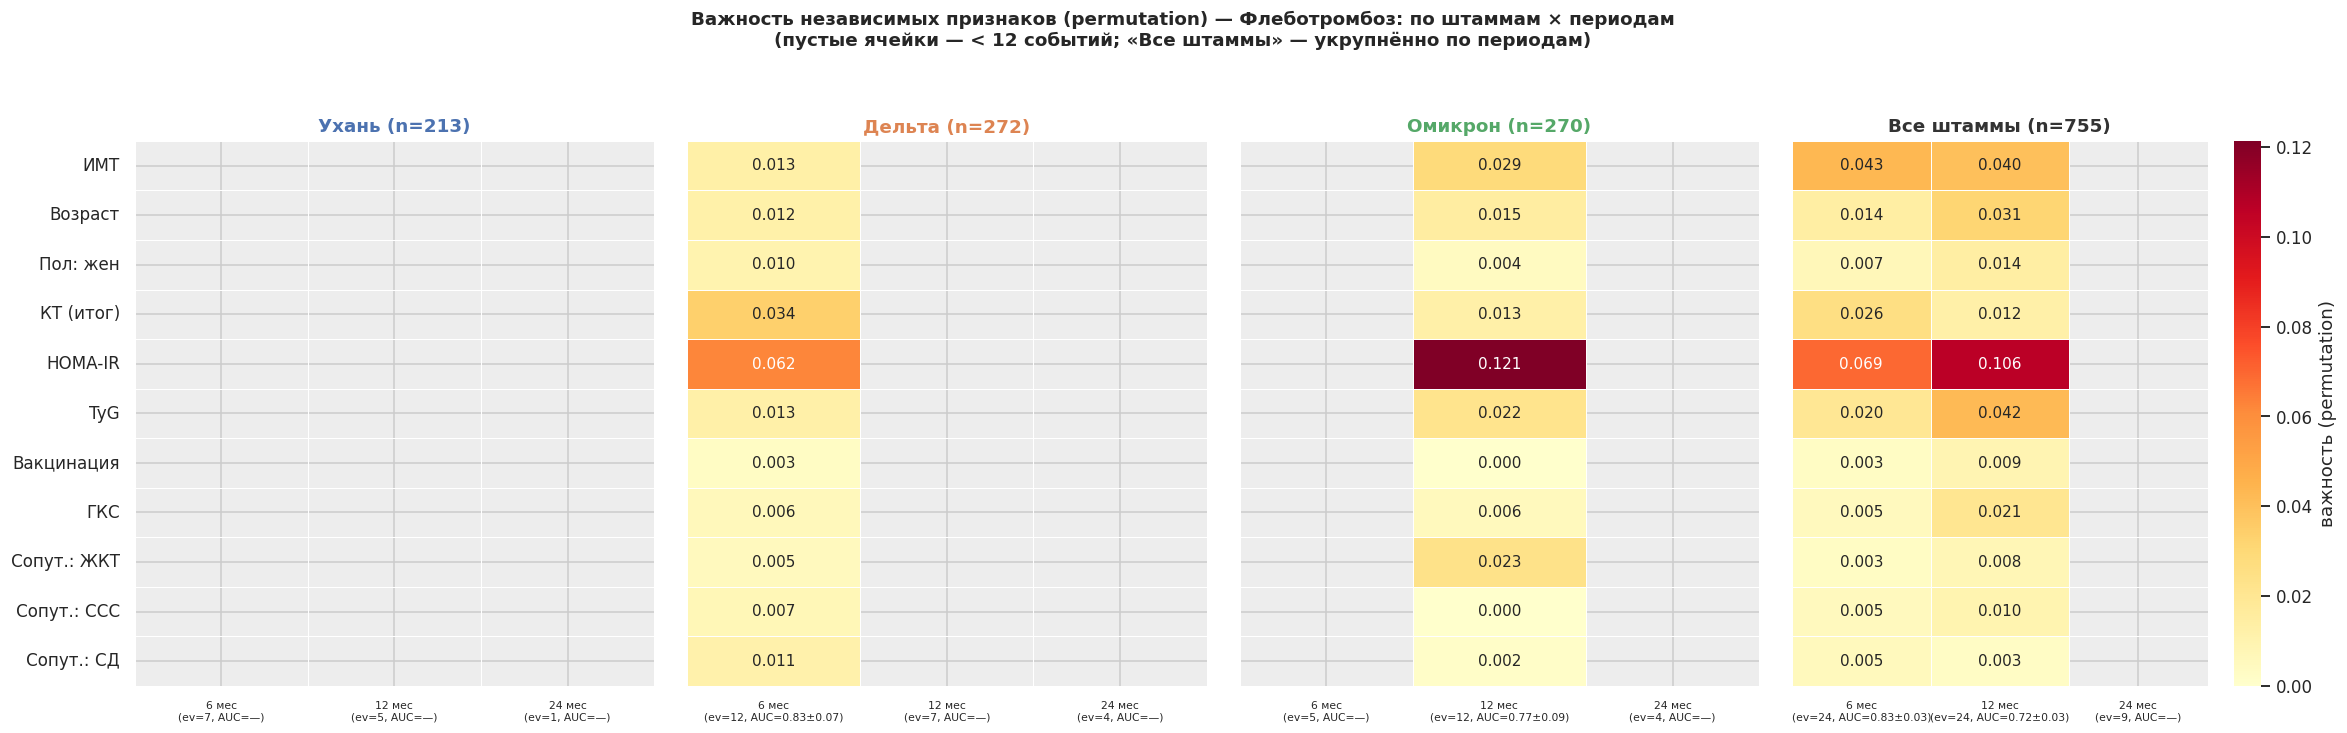

In [22]:
detail_incidence('Флеботромбоз', by_strain=True)
detail_importance('Флеботромбоз', by_strain=True)

## 5.5 ОНМК / ИМ — общий (все штаммы), только по периодам

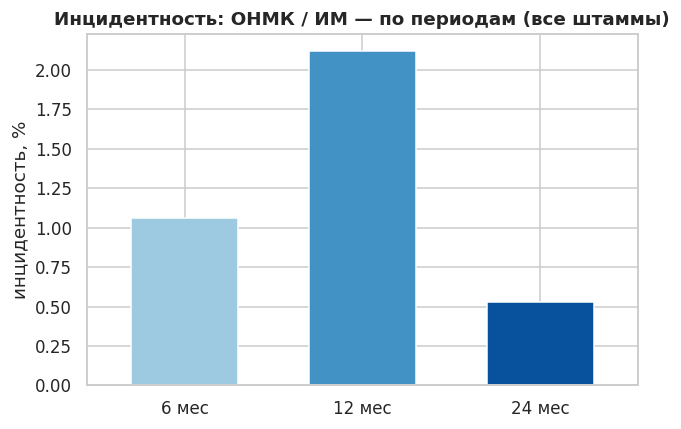

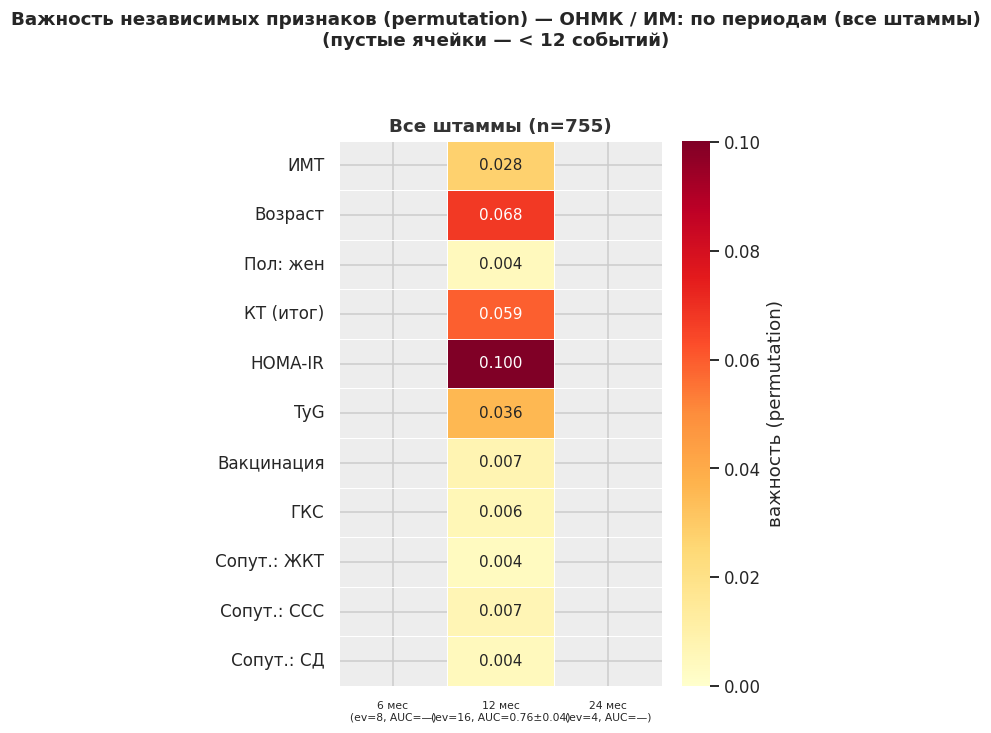

In [23]:
detail_incidence('ОНМК / ИМ', by_strain=False)
detail_importance('ОНМК / ИМ', by_strain=False)

**Как читать часть 5.** Для **рецидивирующих пневмоний** событий достаточно и по штаммам, и по окнам —
видно, как ведущие признаки (HOMA-IR, возраст, ИМТ, TyG) меняются по периодам и геновариантам. Для **ССЗ/АГ**
разбор частично обеспечен. Для **СД, флеботромбоза и ОНМК/ИМ** деление по штамм×период почти всюду
недостаточно (пустые ячейки), поэтому смотрим укрупнённую панель «Все штаммы» — но и там обеспечено событиями
лишь **одно окно 12 мес** для СД и ОНМК/ИМ (единичная оценка) и **6 и 12 мес** для флеботромбоза; это
поисковые оценки. Цветовая шкала общая для панелей, поэтому **величины между панелями напрямую не
сопоставимы** — ориентируйтесь на числа в ячейках. Ячейки, где нижняя граница AUC ≤ 0,5, не показаны.

---
# Выводы

**1. Динамика осложнений по периодам.** В объединённой выборке (и у Ухани и Дельты) инцидентность поздних
осложнений максимальна к **12 месяцам** и снижается к 24; у **Омикрона** она, напротив, продолжает **расти**
к 24 месяцам (7→22→24%). Наиболее частые исходы за весь период — ЖКТ/МАЖБП, рецидивирующие пневмонии,
зрение/слух и ССЗ/АГ.

**2. Предикторы.** Набор **независимых признаков (B)** предсказывает осложнения заметно лучше острых
маркёров (AUC ≈ 0,68–0,84 против 0,61–0,77). По беспристрастной **permutation importance** ведущий предиктор —
**HOMA-IR**, далее **возраст, ИМТ, TyG** и **ГКС**; тяжесть КТ значима в однофакторном OR, но по многофакторной
важности занимает средние позиции. Среди острых маркёров сильнее прочих — **СРБ, ЛДГ, IL-6**. Профиль
важности устойчив по окнам 6/12/24.

**3. Повторный COVID-19.** Независимый фактор риска: у перенёсших повторно поздние осложнения возникают
практически у всех (≈100% против ~42%), и по отдельным нозологиям **скорректированное** OR (поправка на
возраст, ИМТ, метаболический фон и др.) остаётся значимо > 1 (ССЗ/АГ ~2,1; зрение/слух ~3,0; рецидив.
пневмонии ~9,8; ЖКТ ~2,8; психика ~2,8).

**4. Штаммы.** Частоты осложнений различаются между геновариантами (часть — после FDR-поправки; редкие
нозологии исключены из FDR-пула), но ядро предикторов (**HOMA-IR, возраст, ИМТ, TyG**) воспроизводится во
всех штаммах; различия частично объясняются составом групп.

**5. SHAP.** Согласуется с permutation importance: риск «любого осложнения» определяют прежде всего
**HOMA-IR**, возраст, ИМТ и TyG, с плавным смещением вкладов между штаммами и периодами.

**Ограничения.** Наблюдательный дизайн (ассоциации, не причинность); редкие нозологии (онкология, некроз,
панкреонекроз, АСТМА, пневмофиброз) недостаточно обеспечены событиями и в основные модели не включены —
для них приведены только частоты. Для **ОНМК/ИМ, СД и флеботромбоза** в Части 5 приведены **поисковые**
укрупнённые оценки важности (только по обеспеченным событиями окнам) наряду с частотами. Важность признаков
оценена permutation importance **на обучающей выборке** (беспристрастна к типу признака, но несколько
оптимистична на малых подвыборках); AUC приведён с SD по повторной кросс-валидации, ненадёжные ячейки
(нижняя граница AUC ≤ 0,5) в Части 5 не показаны. Внутриштаммовые и попериодные оценки на малых подвыборках
поисковые.
